# Assignment 2: Supervised Learning Methods
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Colour palette
PALETTE     = ['#4A90D9', '#E8603C', '#2EAF7D', '#9B59B6', '#F39C12', '#C0392B', '#1ABC9C']
CLR_BEN     = '#4A90D9'    # benign     → steel blue
CLR_MAL     = '#E8603C'    # malignant  → vermilion
PALETTE_DIV = 'RdBu_r'
PALETTE_SEQ = 'YlOrRd'

sns.set_theme(
    style='whitegrid',
    palette=PALETTE,
    font='DejaVu Sans',
    font_scale=1.1,
    rc={
        'figure.dpi'        : 120,
        'figure.figsize'    : (12, 5),
        'axes.spines.top'   : False,
        'axes.spines.right' : False,
        'axes.titleweight'  : 'bold',
        'axes.titlesize'    : 15,
        'axes.labelsize'    : 13,
        'xtick.labelsize'   : 12,
        'ytick.labelsize'   : 12,
        'legend.frameon'    : False,
        'legend.fontsize'   : 11,
    }
)
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


---
# Task 1: Data Loading and Exploration
Dataset: Breast Cancer Wisconsin (Diagnostic)

> Target handling: y is separated from X immediately and not used to make any preprocessing or feature-selection decisions (to avoid target leakage). It is used posteriorly for training in further tasks.

---
### 1.1 Load Dataset

The dataset is loaded directly from `sklearn.datasets`. Features and target are immediately separated into `X` and `y`.

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')   # 0 = malignant, 1 = benign

print(f"{'Samples:'} {X.shape[0]}")
print(f"{'Features:'} {X.shape[1]}")
print("Target encoding:", "0 = malignant  |  1 = benign")
print(f"{'Missing values'} {X.isnull().sum().sum()}")
print()
X.head()

Samples: 569
Features: 30
Target encoding: 0 = malignant  |  1 = benign
Missing values 0



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Zero missing values across all 30 features, therefore, no imputation is required.


### Feature Descriptions

Each of the 10 real-valued nucleus measurements below is computed as **mean**, **standard error (SE)**, and **worst** (largest observed value across the image), resultin in **30 features** in total.

| Feature | Group | Description |
|---|---|---|
| `radius` | Radius | Mean distance from centre to perimeter |
| `texture` | Texture | Standard deviation of grey-scale values |
| `perimeter` | Perimeter | Tumour perimeter |
| `area` | Area | Tumour cross-sectional area |
| `smoothness` | Smoothness | Local variation in radius lengths |
| `compactness` | Compactness | Perimeter² / Area − 1 |
| `concavity` | Concavity | Severity of concave contour portions |
| `concave points` | Concave pts | Number of concave portions of the contour |
| `symmetry` | Symmetry | Symmetry of the cell nucleus |
| `fractal dimension` | Fractal dim. | Coastline approximation − 1 |

> All features are derived from digitised images of fine needle aspirate (FNA) biopsies. They describe the geometry of individual cell nuclei and are purely objective measurements. [1]

---
### 1.2 Data Types and Summary Statistics

In [4]:
dtype_df = pd.DataFrame({
    'dtype'    : X.dtypes,
    'non-null' : X.notnull().sum(),
    'missing'  : X.isnull().sum(),
    'missing %': (X.isnull().sum() / len(X) * 100).round(2),
})

All 30 features are float64 type with zero missing values

In [ ]:
X.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


**Observations:**

- **Extreme scale heterogeneity:** `mean area` spans 143–2,501 mm², while `mean fractal dimension` is confined to 0.050–0.097. This four-order-of-magnitude range makes **feature standardisation essential** before any distance-based or gradient-descent algorithm.

- **Right-skewed distributions:** `mean area`, `mean perimeter`, `mean concavity`, and `mean compactness` all show mean > median (50th percentile), indicating long right tails driven by the most extreme malignant cases. Models sensitive to scale (SVM, KNN) may be influenced by these outliers.


- **Standard error (SE) features** are uniformly small in magnitude (e.g. `radius error` mean ≈ 0.41 mm), confirming they measure within-image measurement precision rather than absolute tumour size.

- **`mean area` has the largest standard deviation** (357 mm²), far exceeding all other features — it will dominate unscaled Euclidean distance calculations.

---
### 1.3 Class Balance

The target is retrieved here for report class proportions.

In [5]:
counts = y.value_counts().sort_index()
total  = len(y)
labels = ['Malignant (0)', 'Benign (1)']

print(f"{'Class':<20} {'Count':>8} {'Percentage':>12}")

for lbl, cnt in zip(labels, counts.values):
    print(f"{lbl:<20} {cnt:>8}   {cnt / total * 100:>8.1f}%")

print(f"{'Total':<20} {total:>8}   {'100.0%':>9}")
print(f"\nImbalance ratio (Benign : Malignant) = {counts[1] / counts[0]:.2f} : 1")
print(f"Minority class (malignant) share      = {counts[0] / total * 100:.1f}%")

Class                   Count   Percentage
Malignant (0)             212       37.3%
Benign (1)                357       62.7%
Total                     569      100.0%

Imbalance ratio (Benign : Malignant) = 1.68 : 1
Minority class (malignant) share      = 37.3%


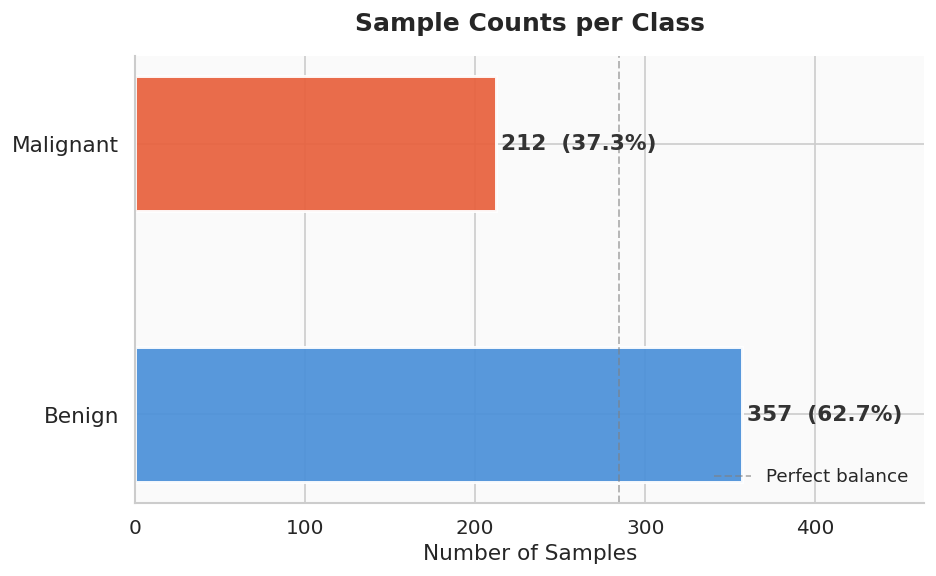

In [6]:
counts_dict = {'Malignant': 212, 'Benign': 357} # Safe mapping
total = sum(counts_dict.values())

clrs       = [CLR_MAL, CLR_BEN]
cls_labels = ['Malignant', 'Benign']

aligned_counts = [counts_dict[label] for label in cls_labels]

fig, ax = plt.subplots(figsize=(8, 5))

plot_labels = cls_labels[::-1]
plot_counts = aligned_counts[::-1]
plot_clrs   = clrs[::-1]

bars = ax.barh(plot_labels, plot_counts,
                color=plot_clrs, height=0.5,
                edgecolor='white', linewidth=1.8, alpha=0.92)

for bar, cnt in zip(bars, plot_counts):
    pct = cnt / total * 100
    ax.text(bar.get_width() + 3,
             bar.get_y() + bar.get_height() / 2,
             f'{cnt}  ({pct:.1f}%)',
             va='center', fontsize=13, fontweight='bold', color='#333333')

ax.set_xlabel('Number of Samples', fontsize=13)
ax.set_title('Sample Counts per Class', fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(0, max(plot_counts) * 1.30)
ax.axvline(total / 2, color='grey', linestyle='--', linewidth=1.2,
            alpha=0.55, label='Perfect balance')
ax.legend(fontsize=11, loc='lower right')
ax.tick_params(axis='y', labelsize=13)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.show()


The dataset contains **357 benign (62.7%)** and **212 malignant (37.3%)** samples.
This indicates there's a certain **class imbalance** favouring the benign class. This implies:

| Implication | Details |
|---|---|
| **Stratified splitting** | Essential to preserve the ratio in train/test sets |
| **Metric choice** | Accuracy alone is misleading, a naïve all-benign classifier scores 62.7%. F1-score (macro), AUC, and recall are more informative [2] |
| **Clinical asymmetry** | A false negative (malignant predicted as benign) carries far higher clinical cost than a false positive |

---
### 1.4 Feature Distributions by Class

Strong vertical separation between malignant (orange) and benign (blue) boxes indicates high discriminative power for that feature.

In [7]:
# Group features by statistical aggregate
mean_feats  = [c for c in X.columns if c.startswith('mean')]
se_feats    = [c for c in X.columns if c.endswith('error')]
worst_feats = [c for c in X.columns if c.startswith('worst')]

short_lbl = (lambda feat:
    feat.replace('mean ', '').replace(' error', '').replace('worst ', '').title())

# Merged DataFrame for plotting (target used ONLY for class colouring here)
X_vis = X.copy()
X_vis['Class'] = y.map({0: 'Malignant', 1: 'Benign'})

print(f"Mean features  ({len(mean_feats)}) : {mean_feats}")
print(f"SE features    ({len(se_feats)}) : {se_feats}")
print(f"Worst features ({len(worst_feats)}) : {worst_feats}")

Mean features  (10) : ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']
SE features    (10) : ['radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error']
Worst features (10) : ['worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [8]:
def plot_distributions(feats, group_title):
    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    axes = axes.flatten()

    for i, feat in enumerate(feats):
        ax = axes[i]

        mal_data = X_vis[X_vis['Class'] == 'Malignant'][feat].values
        ben_data = X_vis[X_vis['Class'] == 'Benign'][feat].values

        bp = ax.boxplot(
            [mal_data, ben_data],
            labels=['Mal.', 'Ben.'],
            patch_artist=True,
            widths=0.42,
            medianprops  ={'color': 'black', 'linewidth': 2.5},
            whiskerprops ={'linewidth': 1.3,  'color': '#555555'},
            capprops     ={'linewidth': 2.0,  'color': '#555555'},
            flierprops   ={'marker': 'o', 'markersize': 3.5,
                           'alpha': 0.35, 'markeredgewidth': 0,
                           'markerfacecolor': '#999999'},
        )
        for box, clr in zip(bp['boxes'], [CLR_MAL, CLR_BEN]):
            box.set_facecolor(clr)
            box.set_alpha(0.65)
            box.set_linewidth(1.8)
            box.set_edgecolor(clr)

        np.random.seed(42)
        for pos, data, clr in [(1, mal_data, CLR_MAL), (2, ben_data, CLR_BEN)]:
            jit = np.random.uniform(-0.17, 0.17, len(data))
            ax.scatter(pos + jit, data, color=clr,
                       alpha=0.22, s=8, zorder=3, linewidths=0)

        ax.set_title(short_lbl(feat), fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(labelsize=11)
        ax.set_facecolor('#fafafa')
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

    mal_patch = mpatches.Patch(facecolor=CLR_MAL, alpha=0.7, label='Malignant')
    ben_patch = mpatches.Patch(facecolor=CLR_BEN, alpha=0.7, label='Benign')
    fig.legend(handles=[mal_patch, ben_patch],
               loc='upper right', fontsize=12,
               frameon=True, framealpha=0.9, edgecolor='#cccccc',
               bbox_to_anchor=(0.99, 0.99))

    fig.suptitle(f'Feature Distributions by Class: {group_title}',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


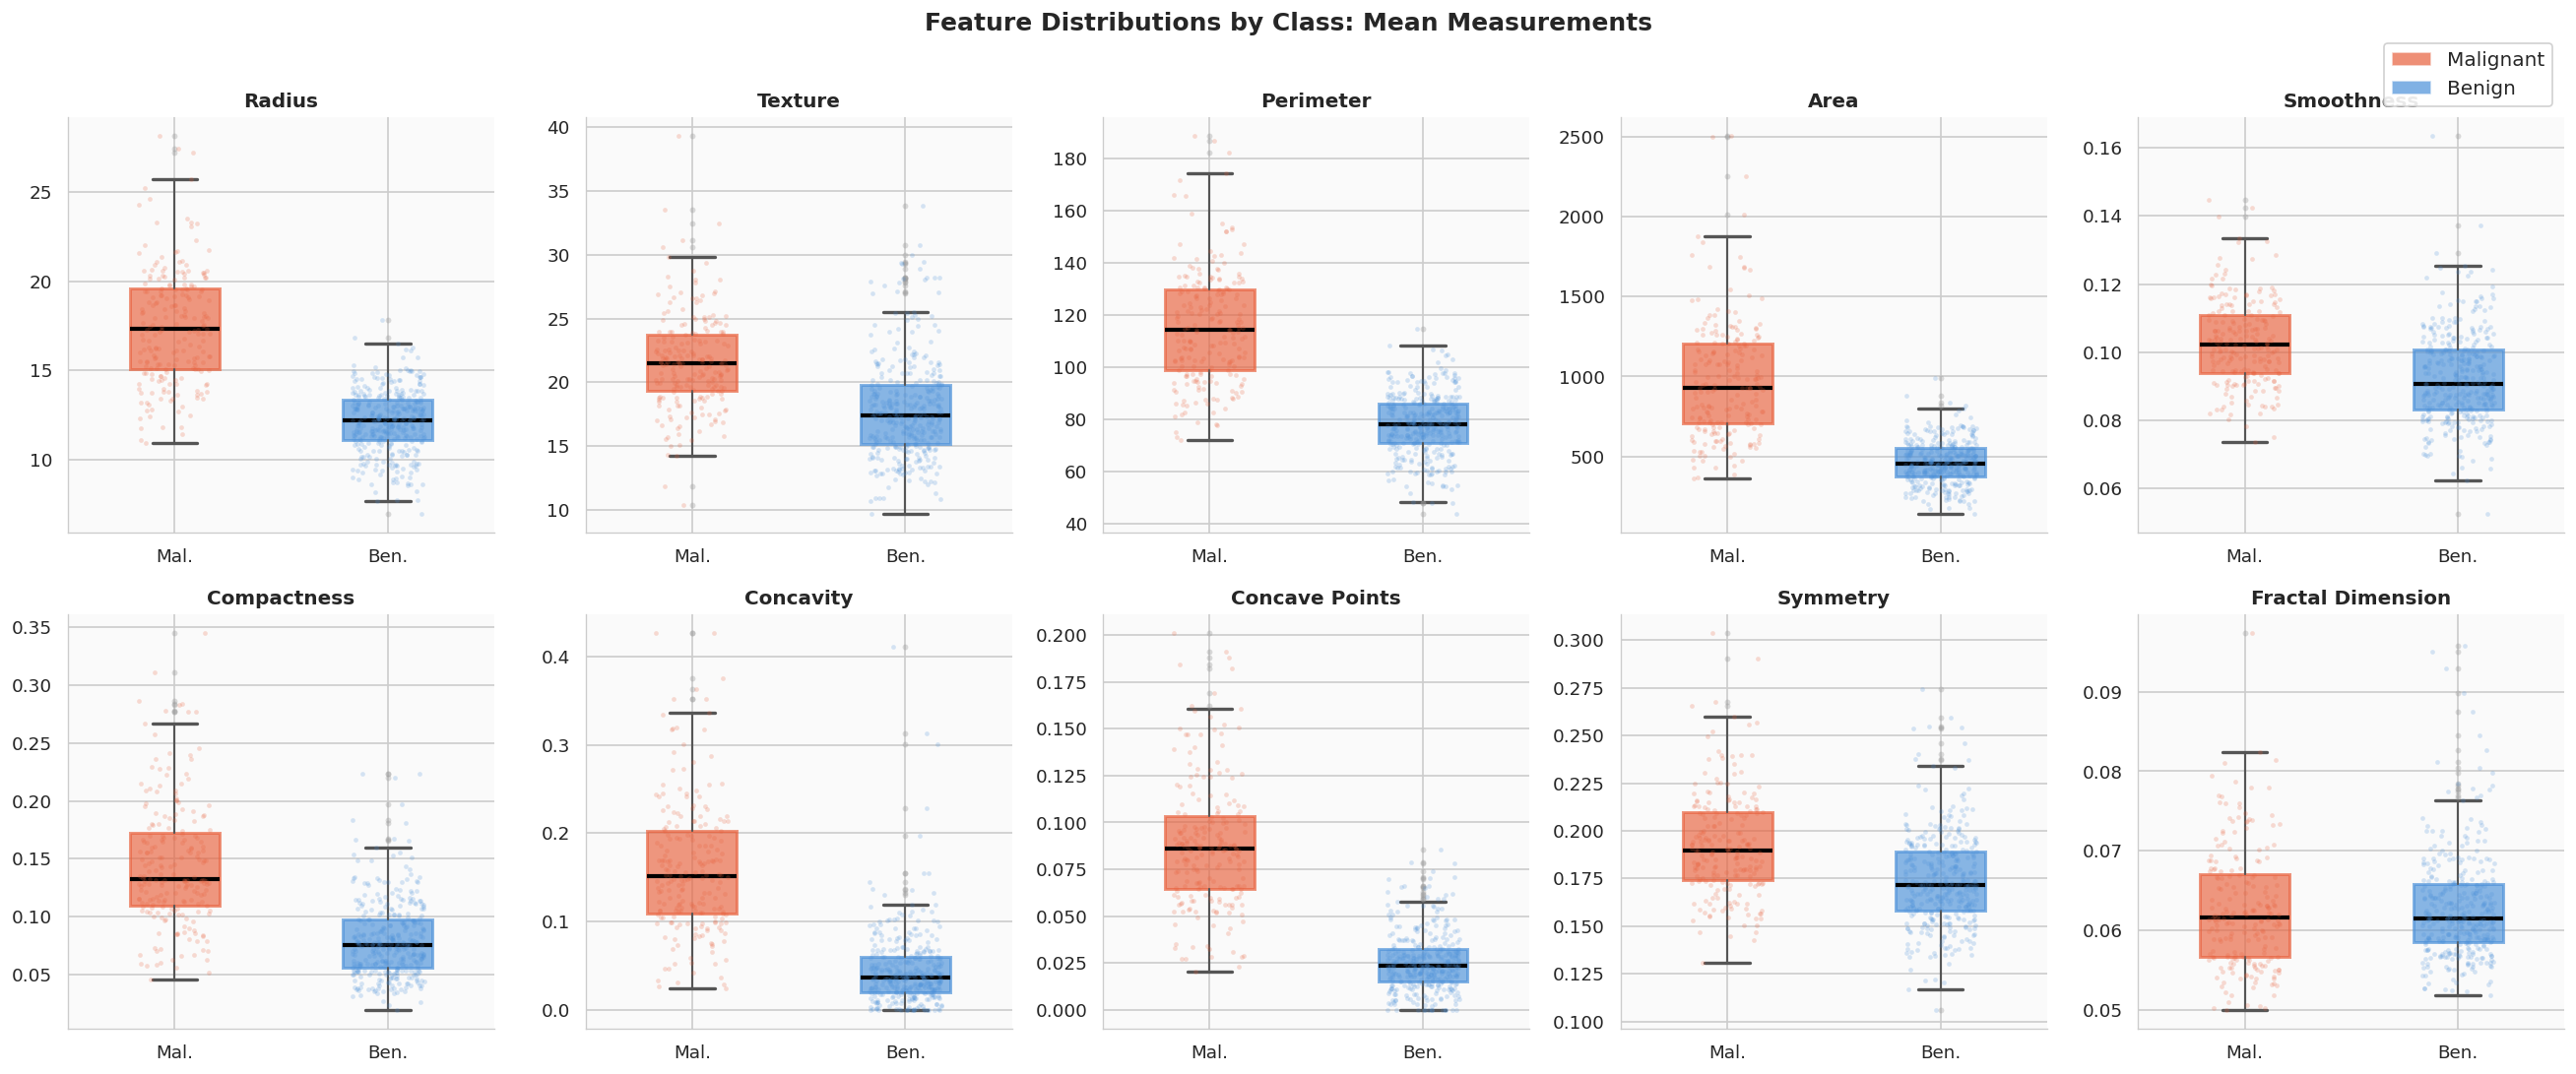

In [9]:
plot_distributions(mean_feats, 'Mean Measurements')

**Observations**

- **`mean radius`, `mean perimeter`, `mean area`** show the strongest class separation: malignant tumours are substantially larger and more variable. It needs to be taken into account that this 3 features are geometrically correlated (area ≈ π·radius², perimeter ≈ 2π·radius).

- **`mean concavity` and `mean concave points`** also separate well, malignant nuclei exhibit more severe and numerous concave contour regions, consistent with the irregular morphology characteristic of cancer cells.

- **`mean compactness`** shows moderate separation with overlapping tails; **`mean smoothness`** and **`mean symmetry`** have considerably more overlap, suggesting lower stand-alone discriminative power.

- **`mean fractal dimension`** is the weakest discriminator, distributions nearly overlap, meaning that complexity of the nuclear outline at the mean level is a poor standalone predictor of malignancy.

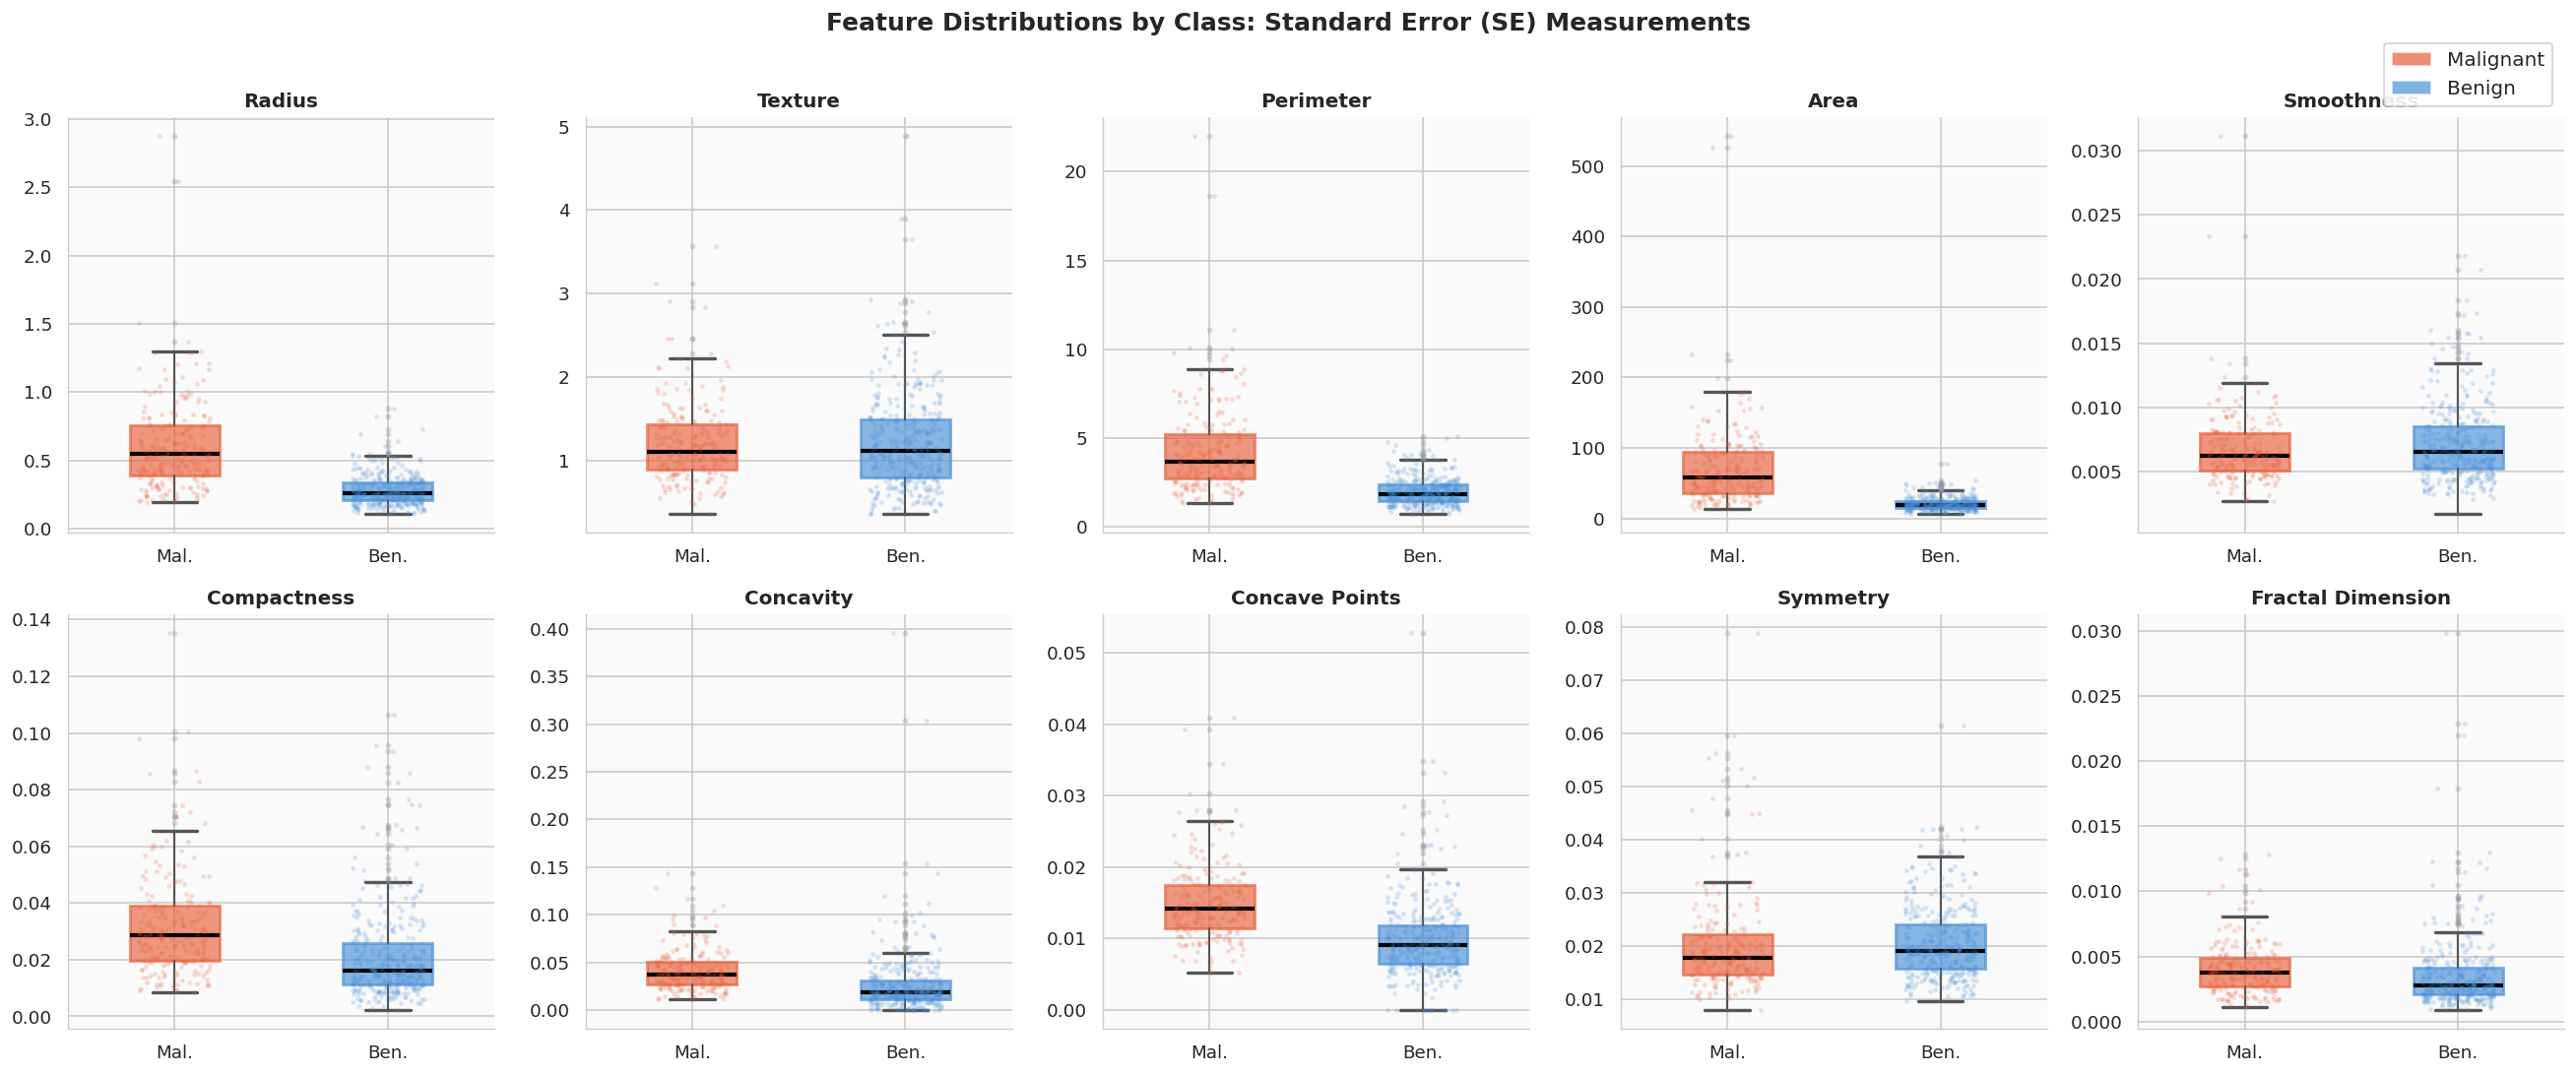

In [10]:
plot_distributions(se_feats, 'Standard Error (SE) Measurements')

**Observations:**

- SE features capture **within-image measurement variability** across the nuclei sampled in each FNA image.
- **`radius error`, `perimeter error`, `area error`** remain informative, with malignant samples showing larger SE, reflecting greater morphological heterogeneity (more diverse cell shapes) within malignant tumours.
- Distributions are **strongly right-skewed** with heavier tails in the malignant class, consistent with the biological expectation that cancer cells are more morphologically diverse.
- Overall, SE features carry **less discriminative power** than mean or worst features, but may provide complementary information in ensemble or regularised models by capturing measurement consistency.

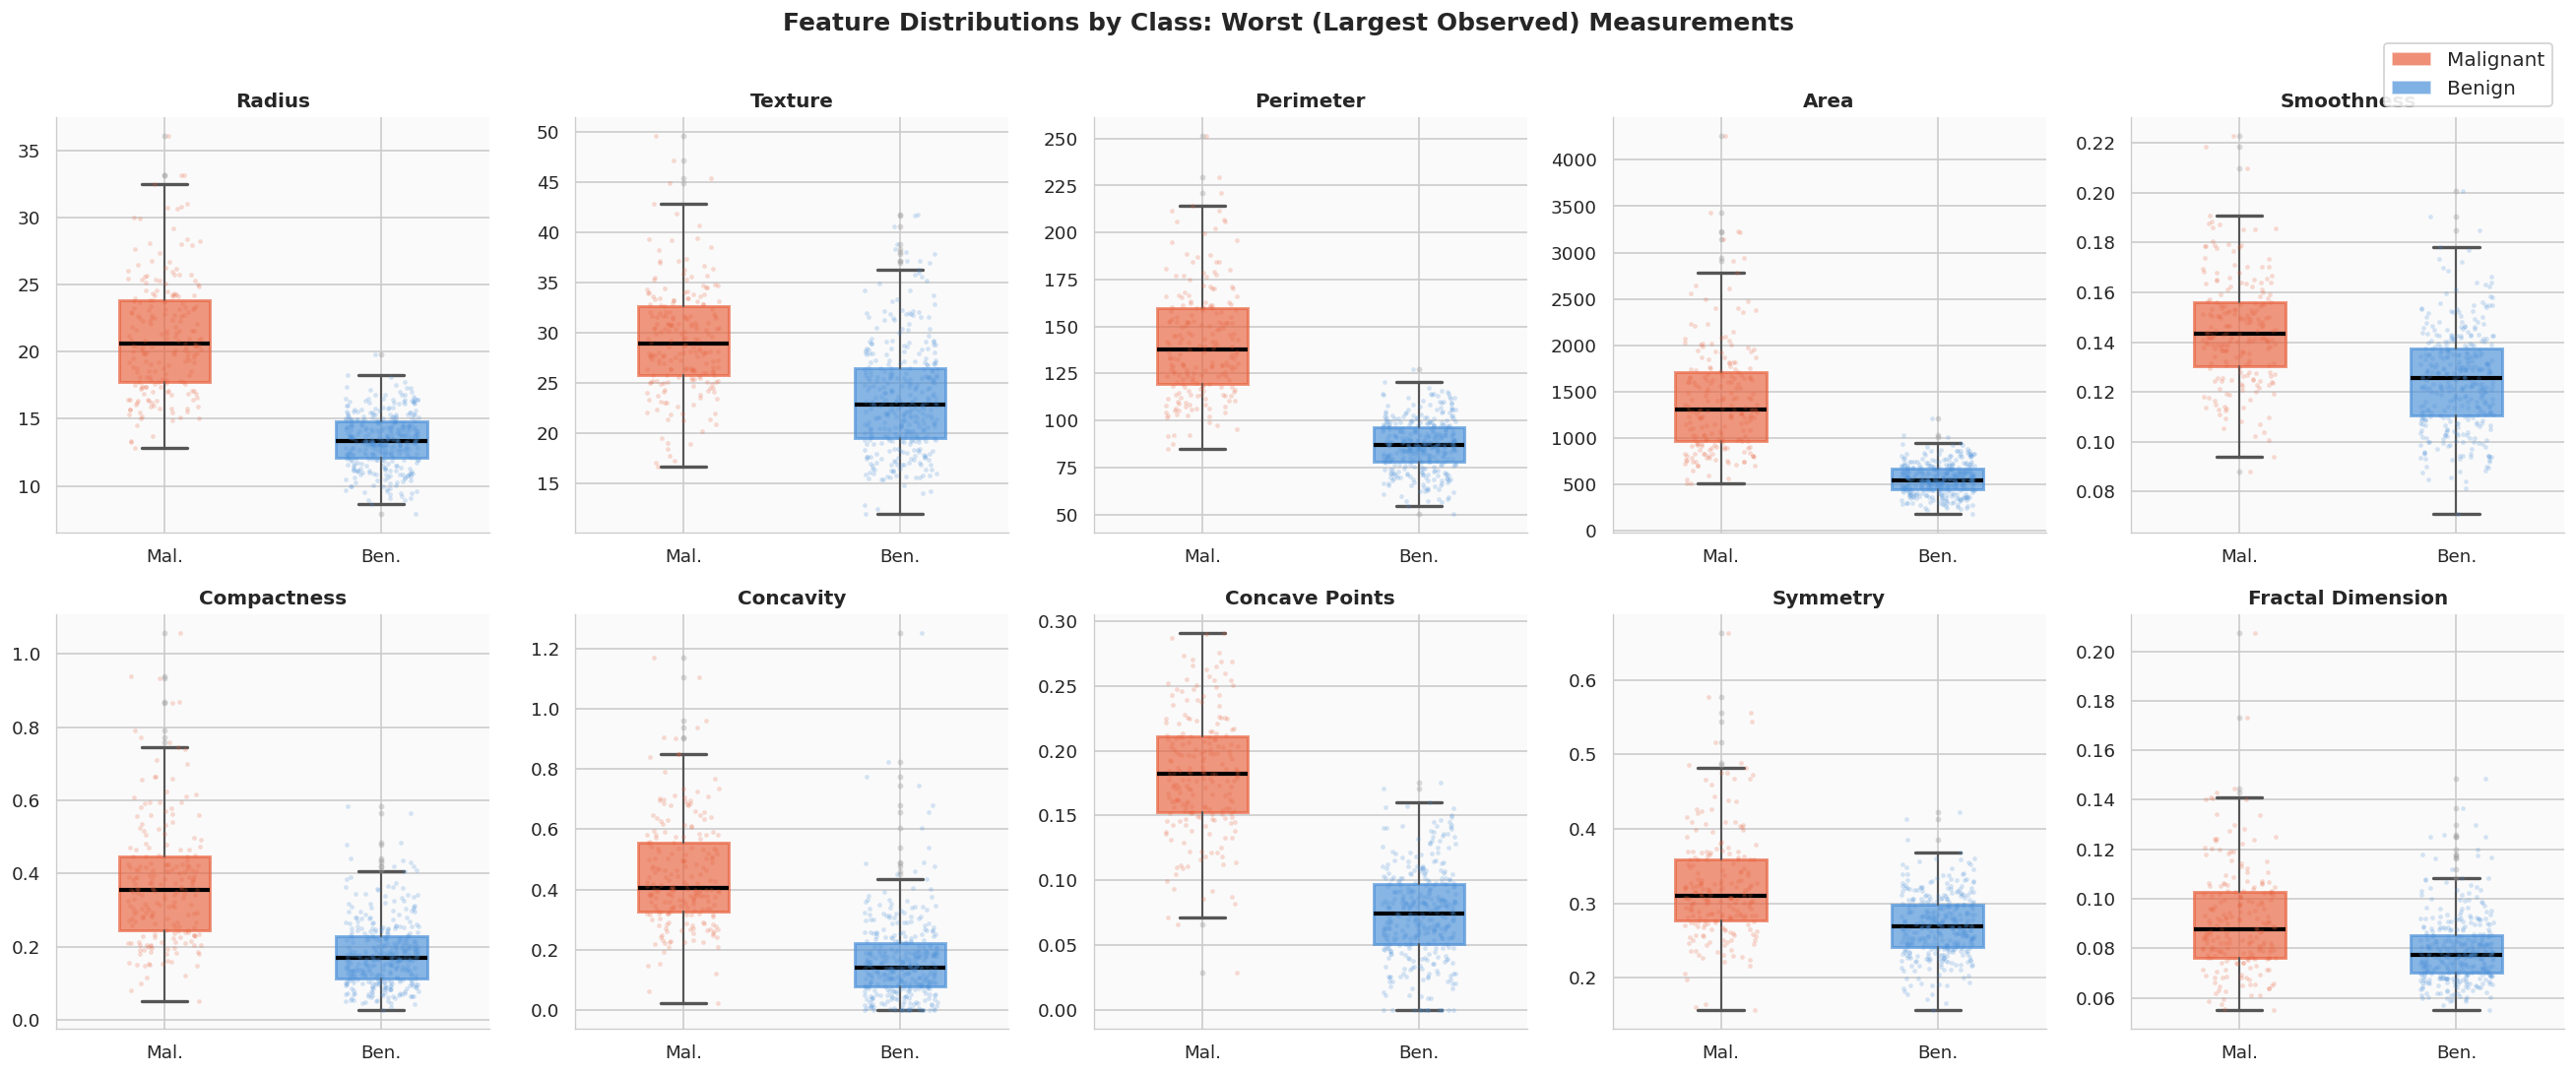

In [11]:
plot_distributions(worst_feats, 'Worst (Largest Observed) Measurements')

**Observations**
The worst features, have an important clinical value, since, most of the times pathologists specifically look for the most abnormal nuclei when assessing malignancy in FNA images. The `worst` statistics formalise this inspection strategy as a quantitative measurement.
- **`worst radius`, `worst perimeter`, `worst area`** display minimal class overlap.
- `worst concavity` and `worst concave points` achieve very good separation.

---
### 1.5 Correlation Analysis

A Pearson correlation matrix is computed for all 30 features.

In [12]:
corr = X.corr()

# Extract all upper-triangle pairs (excluding diagonal)
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
pairs.columns  = ['Feature A', 'Feature B', 'Pearson r']
pairs['|r|']   = pairs['Pearson r'].abs()
pairs          = pairs.sort_values('|r|', ascending=False).reset_index(drop=True)

print(f"Total feature pairs evaluated : {len(pairs)}")
print(f"Pairs with |r| ≥ 0.90         : {(pairs['|r|'] >= 0.90).sum()}")
print(f"Pairs with |r| ≥ 0.95         : {(pairs['|r|'] >= 0.95).sum()}")
print()
print("Top 15 most correlated pairs:")
corr_display_cols = ['Feature A', 'Feature B', 'Pearson r']
print(pairs[corr_display_cols].head(15).to_string(index=False))

Total feature pairs evaluated : 435
Pairs with |r| ≥ 0.90         : 21
Pairs with |r| ≥ 0.95         : 15

Top 15 most correlated pairs:
      Feature A       Feature B  Pearson r
    mean radius  mean perimeter   0.997855
   worst radius worst perimeter   0.993708
    mean radius       mean area   0.987357
 mean perimeter       mean area   0.986507
   worst radius      worst area   0.984015
worst perimeter      worst area   0.977578
   radius error perimeter error   0.972794
 mean perimeter worst perimeter   0.970387
    mean radius    worst radius   0.969539
 mean perimeter    worst radius   0.969476
    mean radius worst perimeter   0.965137
      mean area    worst radius   0.962746
      mean area      worst area   0.959213
      mean area worst perimeter   0.959120
   radius error      area error   0.951830


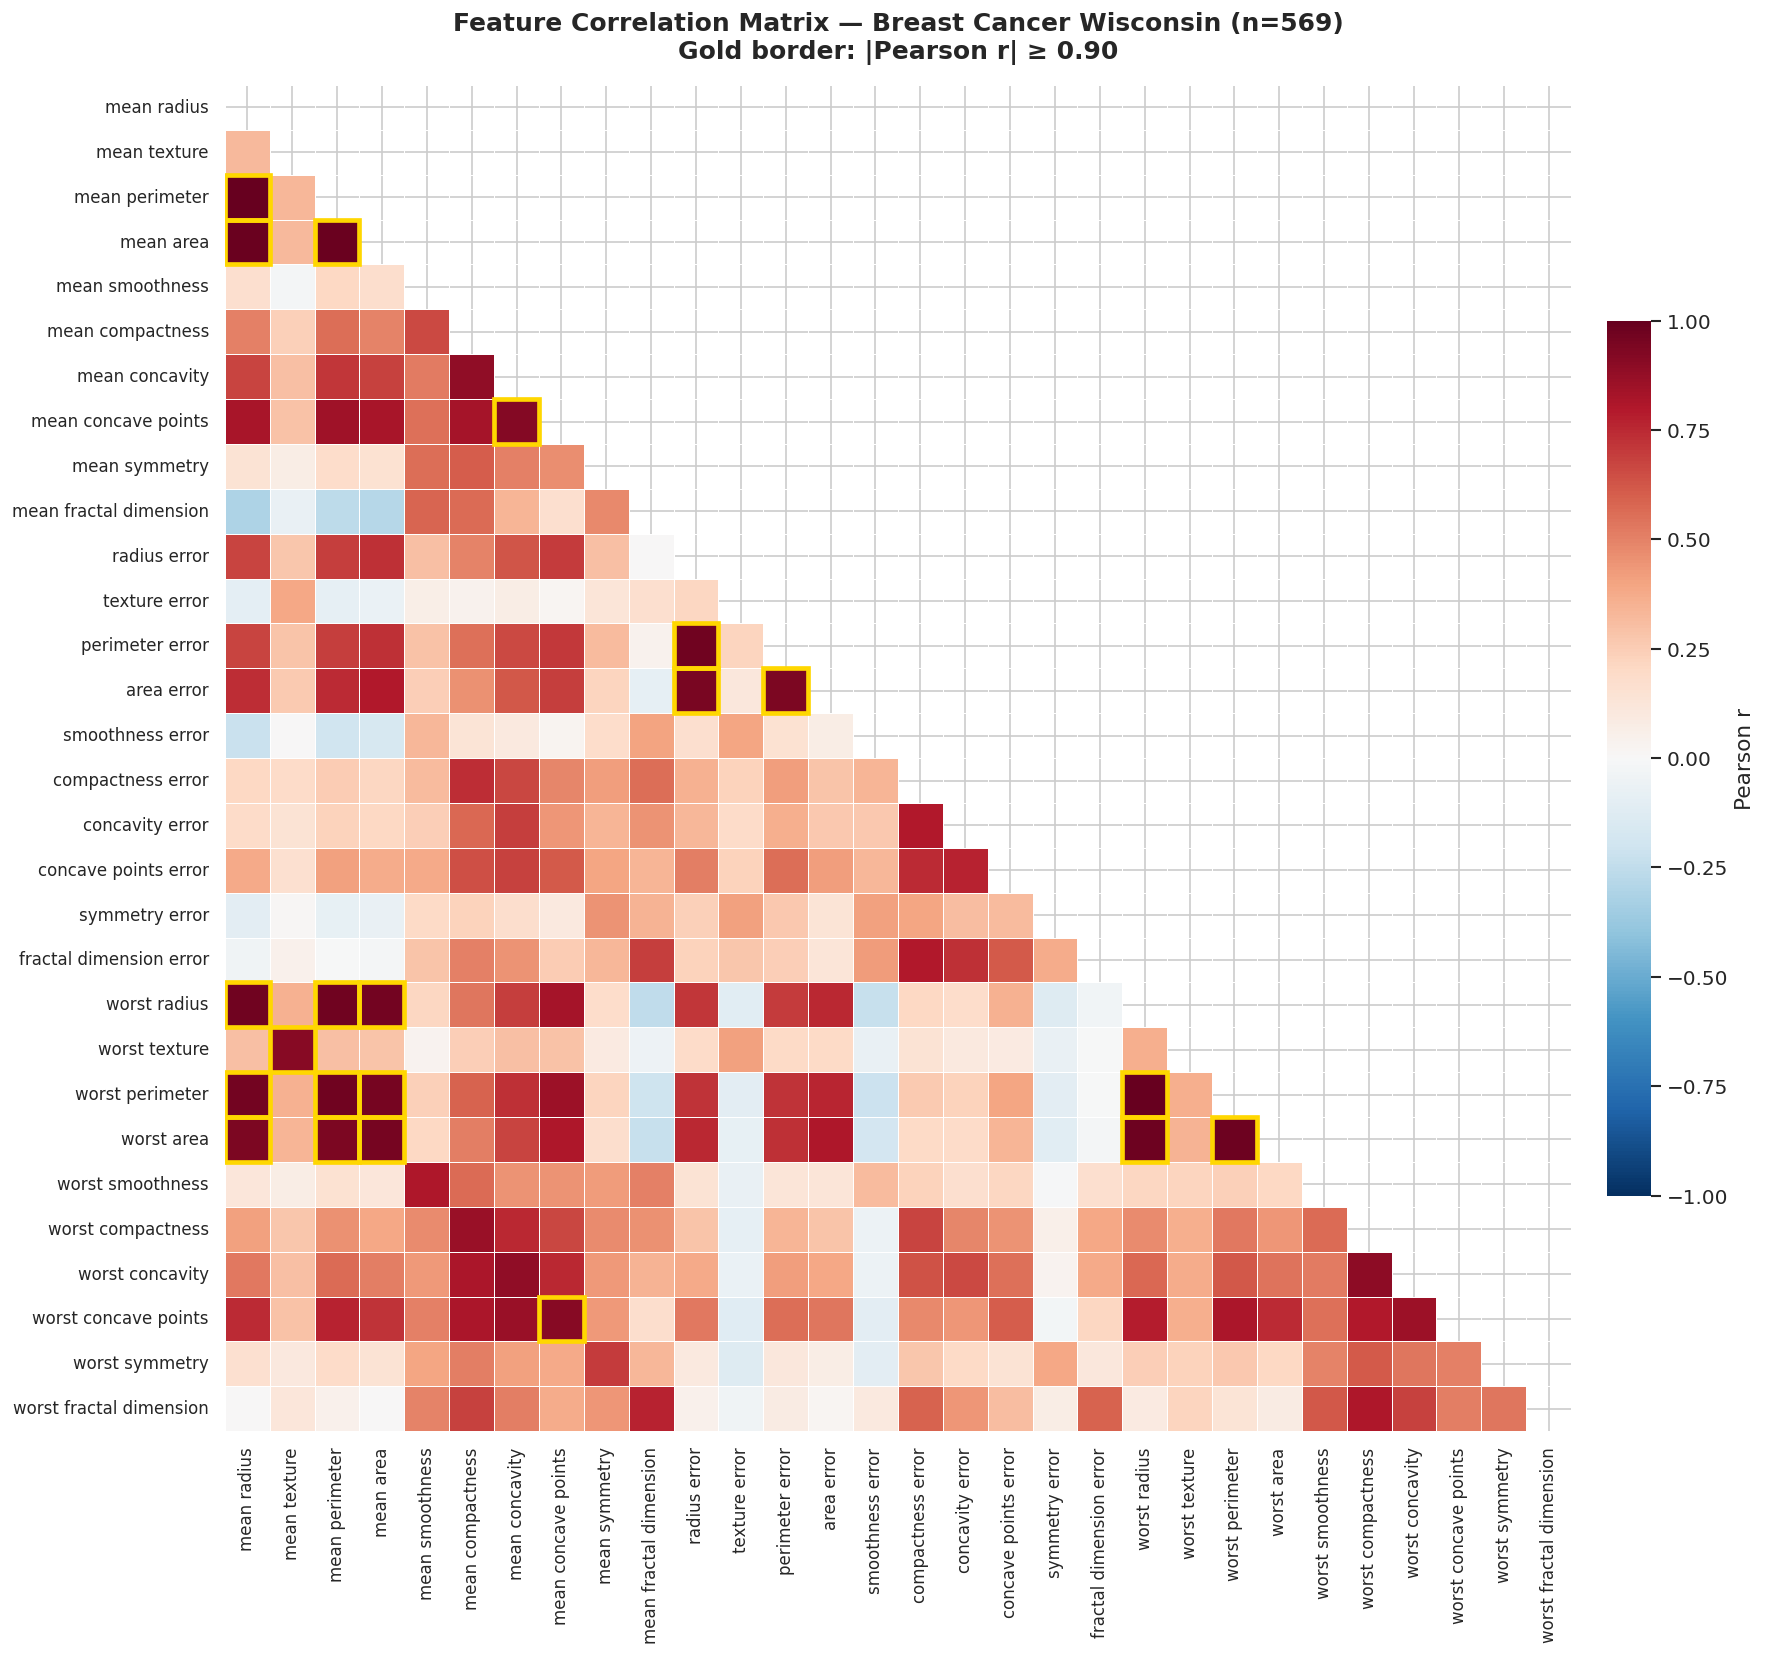

In [13]:
fig, ax = plt.subplots(figsize=(17, 14))

mask = np.triu(np.ones_like(corr, dtype=bool))

hm = sns.heatmap(
    corr, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True,
    linewidths=0.35, linecolor='white',
    ax=ax,
    cbar_kws={
        'shrink'  : 0.65,
        'label'   : 'Pearson r',
        'pad'     : 0.02,
        'ticks'   : [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1],
    }
)

feat_list = list(corr.columns)
for _, row in pairs[pairs['|r|'] >= 0.90].iterrows():
    i = feat_list.index(row['Feature B'])
    j = feat_list.index(row['Feature A'])
    ax.add_patch(plt.Rectangle(
        (j, i), 1, 1, fill=False,
        edgecolor='gold', linewidth=2.8, zorder=5
    ))

ax.set_title(
    'Feature Correlation Matrix — Breast Cancer Wisconsin (n=569)\n'
    'Gold border: |Pearson r| ≥ 0.90',
    fontsize=15, fontweight='bold', pad=16
)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.show()


**Observations:**

The correlation structure reveals three dominant patterns:

**1. Geometric redundancy cluster:** As expected, `radius`, `perimeter`, and `area` are highly correlated since they are mathematically linked. Their mean, SE, and worst variants are all highly correlated (|r| > 0.95), forming a tightly redundant 9-feature cluster. This can lead to multicollinearity.

**2. Cross-aggregate correlation:** The same measurement tracked across its mean, SE, and worst statistics tends to be correlated (e.g. `worst radius` ↔ `mean radius` has |r| ≈ 0.97). Worst values largely track mean values, meaning these aggregates carry partially overlapping information.

**3. Concavity-compactness cluster:** `concavity`, `concave_points`, and `compactness` form a moderate-to-high correlation cluster (|r| ≈ 0.8–0.9), as all three describe the irregularity of the nuclear boundary shape.

---
# Task 2: Preprocessing and Feature Analysis

Prepare the data for modelling: perform a stratified train/test split, apply `StandardScaler` (fit exclusively on training data), and systematically assess candidate features for removal based on correlation and variance criteria.

---
### 2.1 Stratified Train-Test Split

The dataset is partitioned into **80% training (n = 455)** and **20% test (n = 114)** sets.

`stratify=y` ensures that the class proportions (37.3% malignant / 62.7% benign) are **preserved in both subsets**, preventing chance imbalances that could bias evaluation.

> **Data leakage prevention:** The test set is held out entirely. No fitting, scaling, or selection decisions are made using test data. The scaler in Task 2.2 is fit exclusively on `X_train`. [3]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f"{'Split':<12} {'n':>6} {'Malignant':>12} {'Benign':>8} {'Mal%':>7} {'Ben%':>7}")
for name, X_s, y_s in [('Training', X_train, y_train),
                        ('Test',     X_test,  y_test),
                        ('Full',     X,       y)]:
    n_mal = (y_s == 0).sum()
    n_ben = (y_s == 1).sum()
    print(f"{name:<12} {len(y_s):>6} {n_mal:>12} {n_ben:>8} "
          f"{n_mal / len(y_s) * 100:>6.1f}% {n_ben / len(y_s) * 100:>6.1f}%")

print(f"\nX_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}   |  y_test : {y_test.shape}")

Split             n    Malignant   Benign    Mal%    Ben%
Training        455          170      285   37.4%   62.6%
Test            114           42       72   36.8%   63.2%
Full            569          212      357   37.3%   62.7%

X_train : (455, 30)  |  X_test : (114, 30)
y_train : (455,)   |  y_test : (114,)


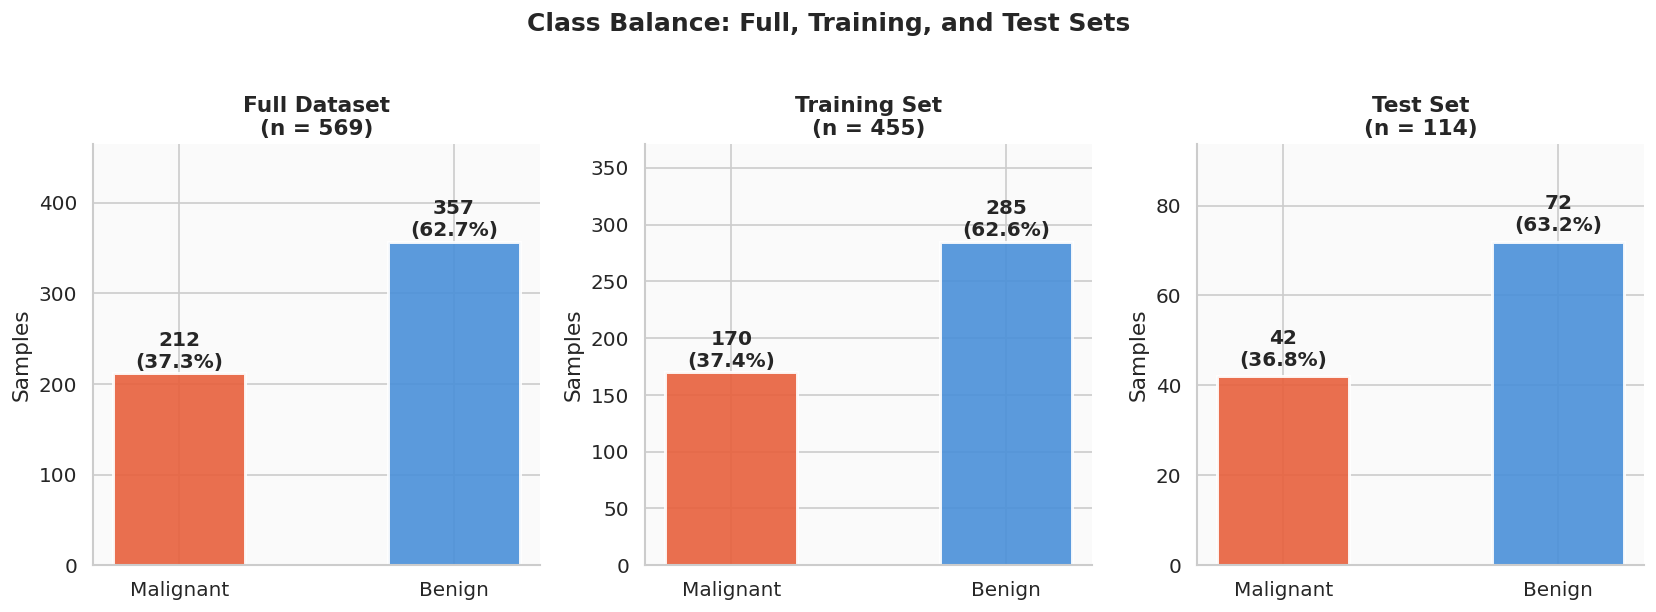

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

splits = [
    ('Full Dataset\n(n = 569)',  y,       ),
    ('Training Set\n(n = 455)',  y_train, ),
    ('Test Set\n(n = 114)',      y_test,  ),
]

for ax, (title, y_s) in zip(axes, splits):
    cnts = y_s.value_counts().sort_index()
    bars = ax.bar(
        ['Malignant', 'Benign'], cnts.values,
        color=[CLR_MAL, CLR_BEN], width=0.48,
        edgecolor='white', linewidth=1.8, alpha=0.90
    )
    for bar, cnt in zip(bars, cnts.values):
        pct = cnt / len(y_s) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f'{cnt}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold'
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Samples', fontsize=13)
    ax.set_ylim(0, max(cnts.values) * 1.30)
    ax.tick_params(labelsize=12)
    ax.set_facecolor('#fafafa')

fig.suptitle('Class Balance: Full, Training, and Test Sets',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Stratification verification:**

| Split | n | Malignant | Benign | Mal % | Ben % |
|---|---|---|---|---|---|
| Full dataset | 569 | 212 | 357 | 37.3% | 62.7% |
| Training set | 455 | 170 | 285 | 37.4% | 62.6% |
| Test set | 114 | 42 | 72 | 36.8% | 63.2% |

The class proportions are **preserved to within < 0.5 percentage points** across all splits, confirming correct stratification. The minor deviation in the test set is expected from rounding when partitioning a finite sample.

---
### 2.2 Feature Scaling with StandardScaler

`StandardScaler` transforms each feature to zero mean and unit variance using training-set statistics:

$$z = \frac{x - \hat{\mu}_{\text{train}}}{\hat{\sigma}_{\text{train}}}$$


In [16]:
scaler = StandardScaler()

# Fit on training data only; transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)          # no .fit() here

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

# Verification
train_means = X_train_scaled.mean().abs()
train_stds  = X_train_scaled.std()
test_means  = X_test_scaled.mean().abs()

print("Post-scaling verification:")
print(f"  Training set max |mean|  : {train_means.max():.2e}  (expected ≈ 0)")
print(f"  Training set mean std    : {train_stds.mean():.6f}  (expected ≈ 1)")
print(f"  Training set min std     : {train_stds.min():.6f}")
print(f"  Training set max std     : {train_stds.max():.6f}")
print()
print(f"  Test set max |mean|      : {test_means.max():.4f}  (expected ≠ 0, leakage check)")

Post-scaling verification:
  Training set max |mean|  : 5.68e-15  (expected ≈ 0)
  Training set mean std    : 1.001101  (expected ≈ 1)
  Training set min std     : 1.001101
  Training set max std     : 1.001101

  Test set max |mean|      : 0.1349  (expected ≠ 0, leakage check)


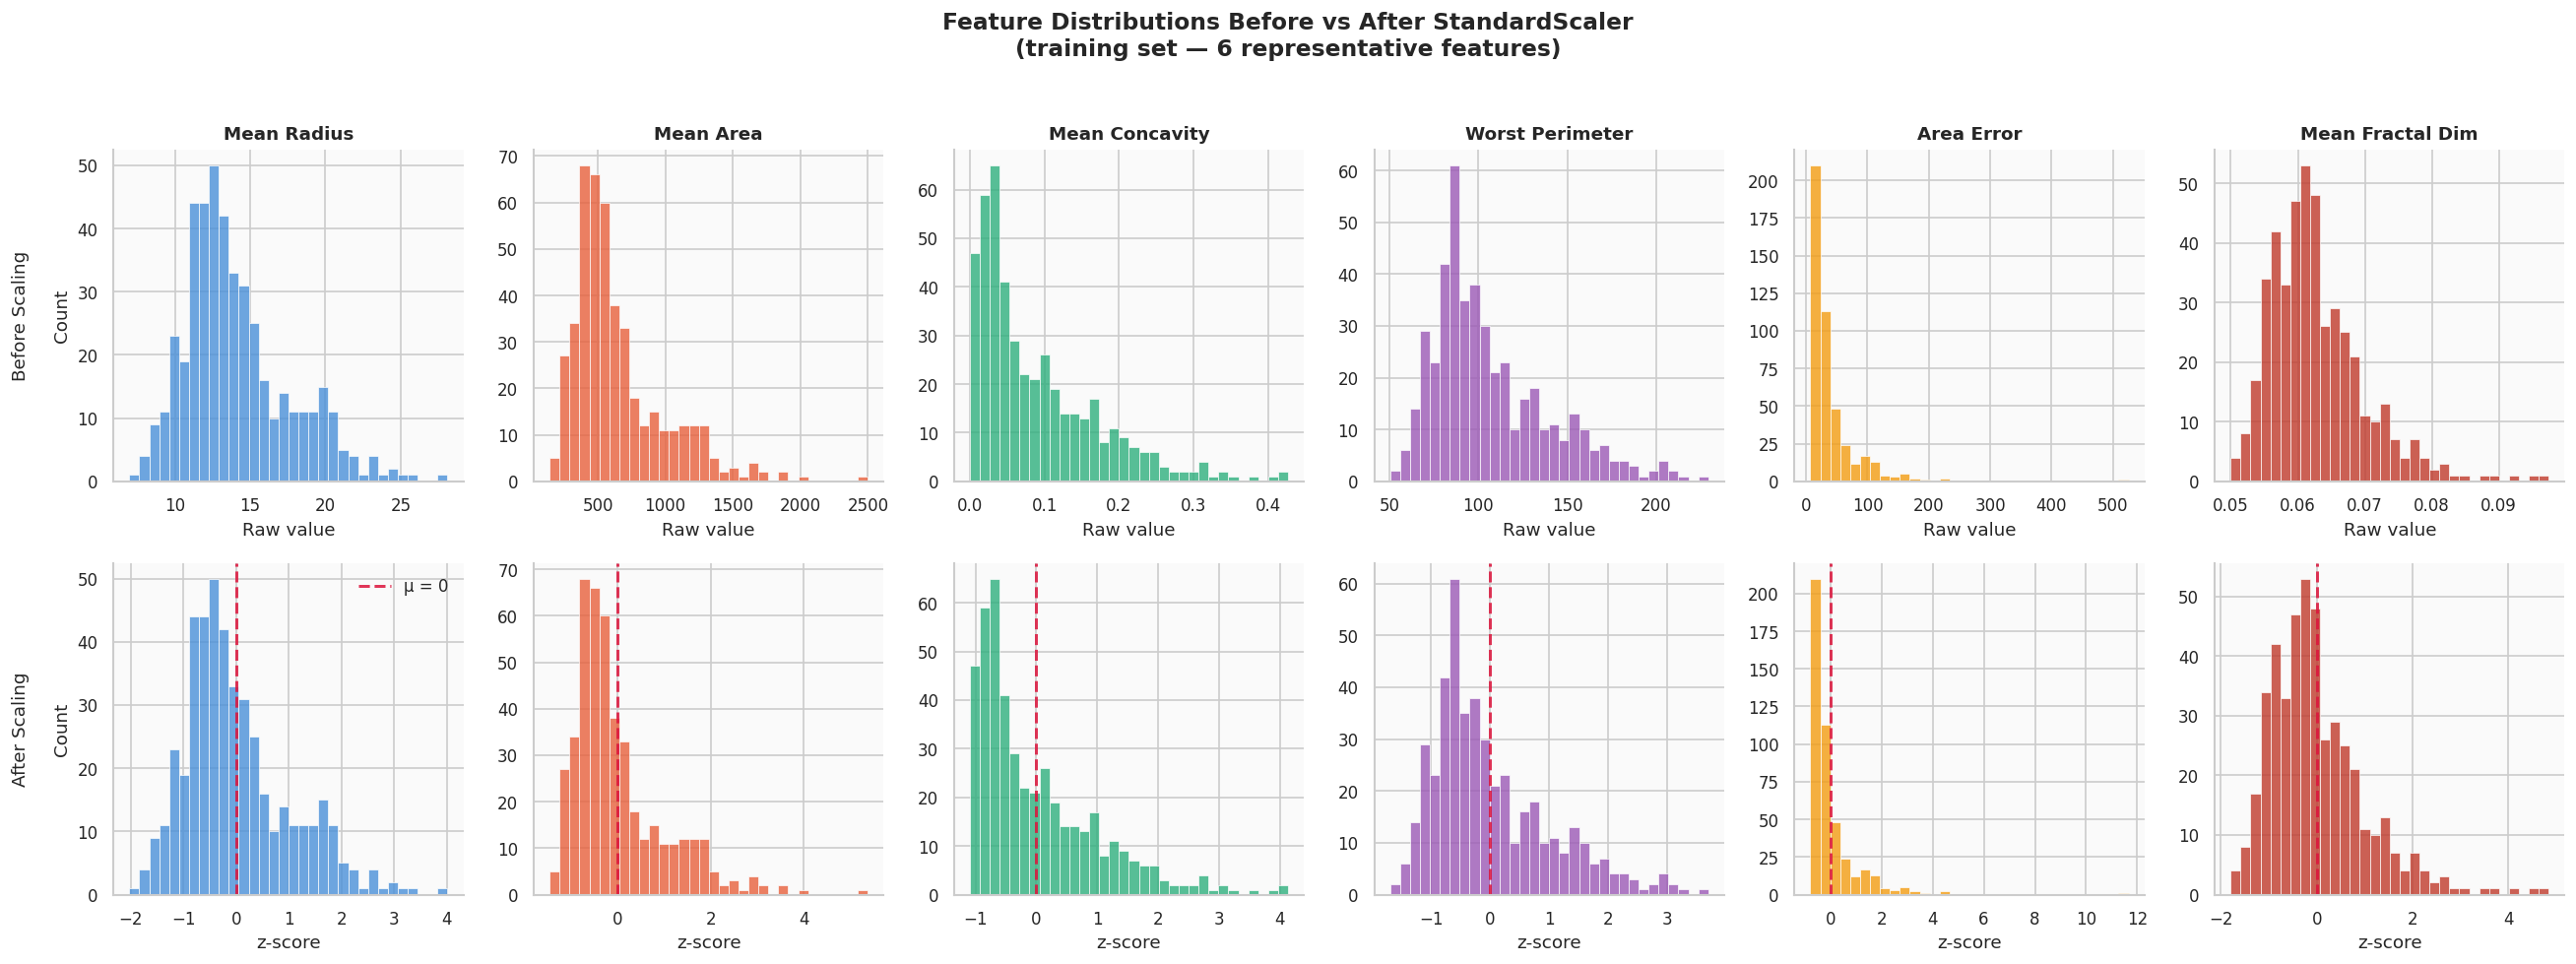

In [17]:
sample_feats = [
    'mean radius', 'mean area', 'mean concavity',
    'worst perimeter', 'area error', 'mean fractal dimension'
]
display_names = [
    'Mean Radius', 'Mean Area', 'Mean Concavity',
    'Worst Perimeter', 'Area Error', 'Mean Fractal Dim'
]

fig, axes = plt.subplots(2, 6, figsize=(22, 8))

for col, (feat, dname) in enumerate(zip(sample_feats, display_names)):
    clr = PALETTE[col % len(PALETTE)]

    ax_top = axes[0, col]
    ax_top.hist(X_train[feat], bins=32, color=clr,
                alpha=0.80, edgecolor='white', linewidth=0.5)
    ax_top.set_title(dname, fontsize=11, fontweight='bold')
    if col == 0:
        ax_top.set_ylabel('Before Scaling\n\nCount', fontsize=11, labelpad=4)
    ax_top.set_xlabel('Raw value', fontsize=11)
    ax_top.set_facecolor('#fafafa')
    ax_top.tick_params(labelsize=10)

    ax_bot = axes[1, col]
    ax_bot.hist(X_train_scaled[feat], bins=32, color=clr,
                alpha=0.80, edgecolor='white', linewidth=0.5)
    ax_bot.axvline(0, color='crimson', linestyle='--',
                   linewidth=1.8, alpha=0.85, label='μ = 0')
    if col == 0:
        ax_bot.set_ylabel('After Scaling\n\nCount', fontsize=11, labelpad=4)
        ax_bot.legend(fontsize=10)
    ax_bot.set_xlabel('z-score', fontsize=11)
    ax_bot.set_facecolor('#fafafa')
    ax_bot.tick_params(labelsize=10)

fig.suptitle(
    'Feature Distributions Before vs After StandardScaler\n'
    '(training set — 6 representative features)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


**Scaling outcome:**

- All features are now expressed as **z-scores** (mean = 0, SD = 1) on the training set.
- The **shape** of each distribution is preserved: `StandardScaler` is a linear transformation and does not affect normality, skewness, or the relative presence of outliers.
- Features previously spanning wildly different magnitudes (e.g. `mean area` ≈ 0–2,500 vs `mean fractal dimension` ≈ 0.05–0.10) are now directly comparable on the same z-score axis.
- The test set means are **not** exactly 0 (correct behaviour: the test set was scaled with training statistics, not its own).

---
### 2.3 Feature Selection Analysis

Two standard criteria for feature removal are evaluated:

1. **Near-zero variance:** features with insufficient signal variance carry little information for any classifier.
2. **High pairwise correlation:** redundant features inflate model complexity without adding discriminative power and destabilise coefficient-based models.

In [18]:
# Near-zero variance (raw scale, training set)
variances = X_train.var(ddof=1)
std_devs  = X_train.std(ddof=1)
means     = X_train.mean().abs()

# Coefficient of variation: how large is spread relative to mean?
cv = std_devs / means

var_df = pd.DataFrame({
    'variance': variances,
    'std'     : std_devs,
    '|mean|'  : means,
    'CV'      : cv,
}).sort_values('variance')

print("Features sorted by variance (training set, raw scale):")
print(var_df.round(6).to_string())
print()
near_zero = var_df[var_df['variance'] < 1e-4]
print(f"Features with variance < 1e-4 : {len(near_zero)}  (near-zero threshold)")
print(f"Lowest variance  : '{var_df.index[0]}'  (var = {var_df['variance'].iloc[0]:.6f})")
print(f"Highest variance : '{var_df.index[-1]}'  (var = {var_df['variance'].iloc[-1]:.2f})")

Features sorted by variance (training set, raw scale):
                              variance         std      |mean|        CV
fractal dimension error       0.000008    0.002780    0.003797  0.732135
smoothness error              0.000010    0.003135    0.007084  0.442618
concave points error          0.000040    0.006290    0.011673  0.538836
mean fractal dimension        0.000051    0.007159    0.062820  0.113968
symmetry error                0.000077    0.008764    0.020779  0.421770
mean smoothness               0.000181    0.013458    0.096167  0.139940
worst fractal dimension       0.000339    0.018408    0.083945  0.219284
compactness error             0.000341    0.018467    0.025538  0.723109
worst smoothness              0.000509    0.022550    0.132329  0.170410
mean symmetry                 0.000788    0.028074    0.180618  0.155435
concavity error               0.001048    0.032370    0.032552  0.994402
mean concave points           0.001515    0.038925    0.048344  0.805

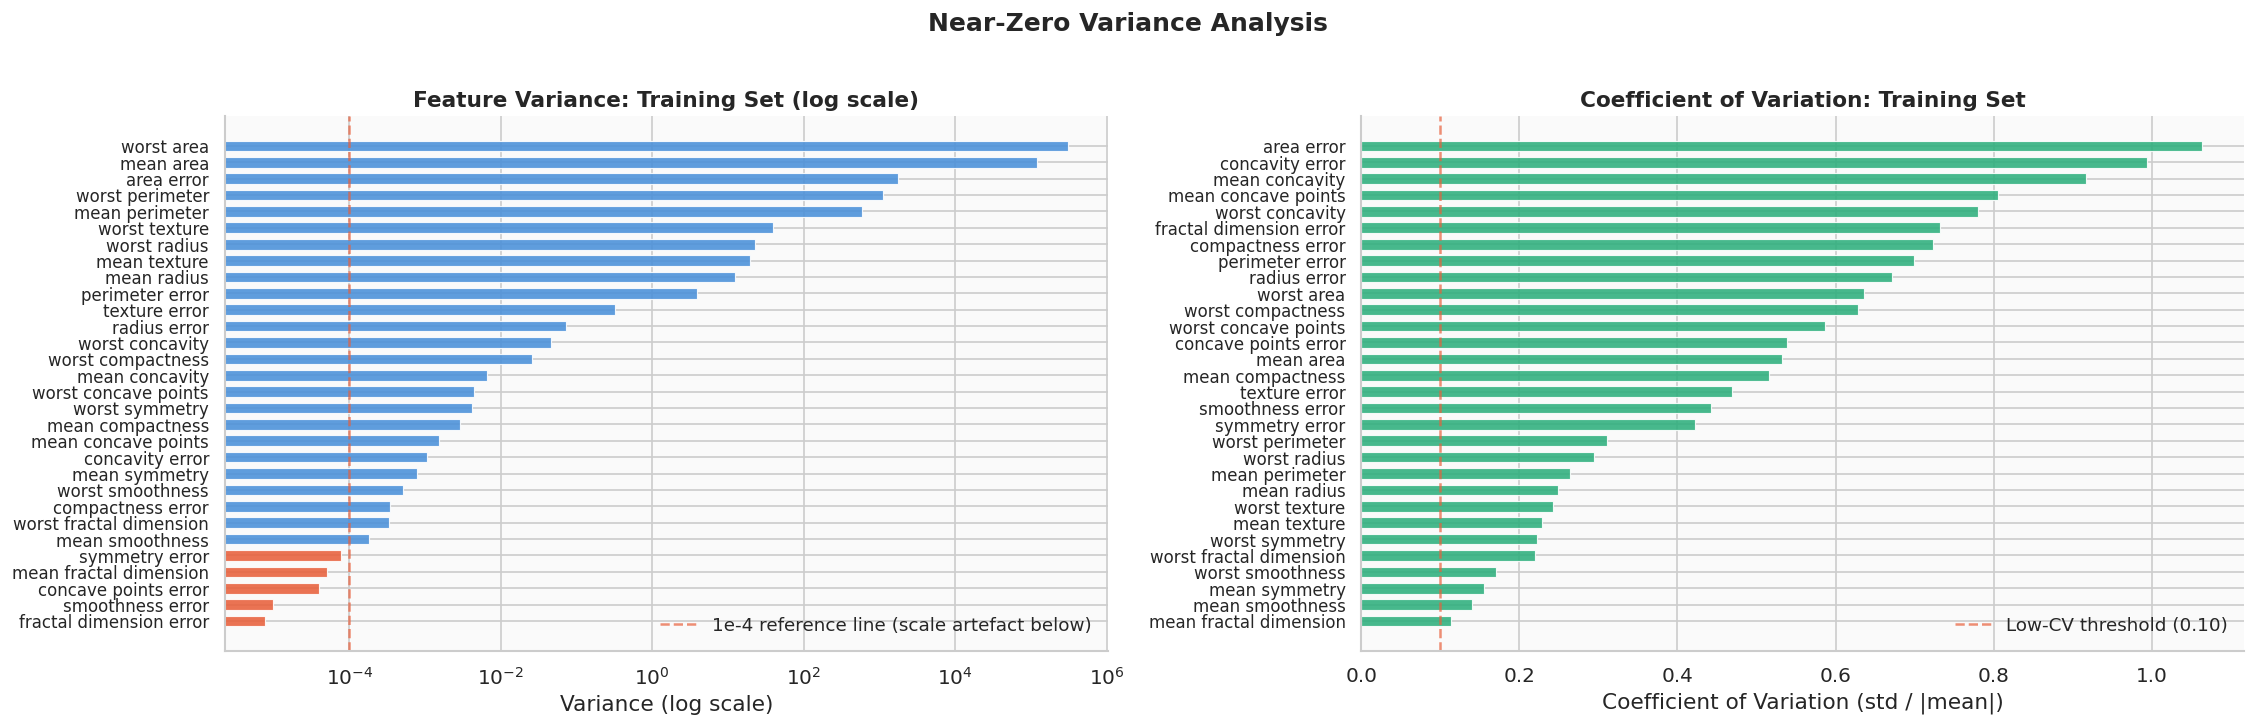

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6))

ax1 = axes[0]
var_s = var_df['variance'].sort_values()
bar_c = [CLR_MAL if v < 1e-4 else PALETTE[0] for v in var_s]
ax1.barh(var_s.index, var_s.values,
         color=bar_c, height=0.65,
         edgecolor='white', linewidth=0.7, alpha=0.88)
ax1.set_xscale('log')
ax1.set_xlabel('Variance (log scale)', fontsize=13)
ax1.set_title('Feature Variance: Training Set (log scale)', fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelsize=10)
ax1.tick_params(axis='x', labelsize=12)
ax1.axvline(1e-4, color=CLR_MAL, linestyle='--', linewidth=1.5,
            alpha=0.7, label='1e-4 reference line (scale artefact below)')
ax1.legend(fontsize=11)
ax1.set_facecolor('#fafafa')

ax2 = axes[1]
cv_s = var_df['CV'].sort_values()
bar_c2 = [CLR_MAL if v < 0.1 else PALETTE[2] for v in cv_s]
ax2.barh(cv_s.index, cv_s.values,
         color=bar_c2, height=0.65,
         edgecolor='white', linewidth=0.7, alpha=0.88)
ax2.axvline(0.1, color=CLR_MAL, linestyle='--', linewidth=1.5,
            alpha=0.7, label='Low-CV threshold (0.10)')
ax2.set_xlabel('Coefficient of Variation (std / |mean|)', fontsize=13)
ax2.set_title('Coefficient of Variation: Training Set', fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelsize=10)
ax2.tick_params(axis='x', labelsize=12)
ax2.legend(fontsize=11)
ax2.set_facecolor('#fafafa')

fig.suptitle('Near-Zero Variance Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Variance finding:**

Five features have raw variance < 1e-4 on the training set:
`fractal dimension error` (8e-6), `smoothness error` (1e-5), `concave points error` (4e-5), `mean fractal dimension` (5e-5), and `symmetry error` (8e-5).

This is **not** a signal of low information, it is a **scale artefact**. These features take inherently small absolute values (e.g., `mean fractal dimension` ≈ 0.05–0.10), so their absolute variance is tiny. Their coefficients of variation (std / |mean|) range from 10–15%, indicating meaningful relative variability.

After `StandardScaler`, all 30 features are assigned unit variance and are treated equally by downstream algorithms. **No features are dropped on the basis of near-zero variance.**

The raw-scale variance analysis reinforces, once again, the critical importance of standardisation before any distance- or gradient-based modelling.

In [20]:
# High-correlation candidates
high_corr = pairs[pairs['|r|'] >= 0.90].copy().reset_index(drop=True)

print(f"Feature pairs with |r| ≥ 0.90 : {len(high_corr)}")
print()
print(f"{'Feature A':<28} {'Feature B':<28} {'Pearson r':>10}")
print("─" * 68)
for _, row in high_corr.iterrows():
    print(f"{row['Feature A']:<28} {row['Feature B']:<28} {row['Pearson r']:>10.4f}")

# How often does each feature appear in high-corr pairs?
from collections import Counter
involved = Counter(high_corr['Feature A'].tolist() + high_corr['Feature B'].tolist())
inv_df = (pd.DataFrame.from_dict(involved, orient='index', columns=['high-corr pairs'])
            .sort_values('high-corr pairs', ascending=False))
print(f"\nFeatures most involved in |r| ≥ 0.90 pairs (top 12):")
print(inv_df.head(12).to_string())

Feature pairs with |r| ≥ 0.90 : 21

Feature A                    Feature B                     Pearson r
────────────────────────────────────────────────────────────────────
mean radius                  mean perimeter                   0.9979
worst radius                 worst perimeter                  0.9937
mean radius                  mean area                        0.9874
mean perimeter               mean area                        0.9865
worst radius                 worst area                       0.9840
worst perimeter              worst area                       0.9776
radius error                 perimeter error                  0.9728
mean perimeter               worst perimeter                  0.9704
mean radius                  worst radius                     0.9695
mean perimeter               worst radius                     0.9695
mean radius                  worst perimeter                  0.9651
mean area                    worst radius                     0.962

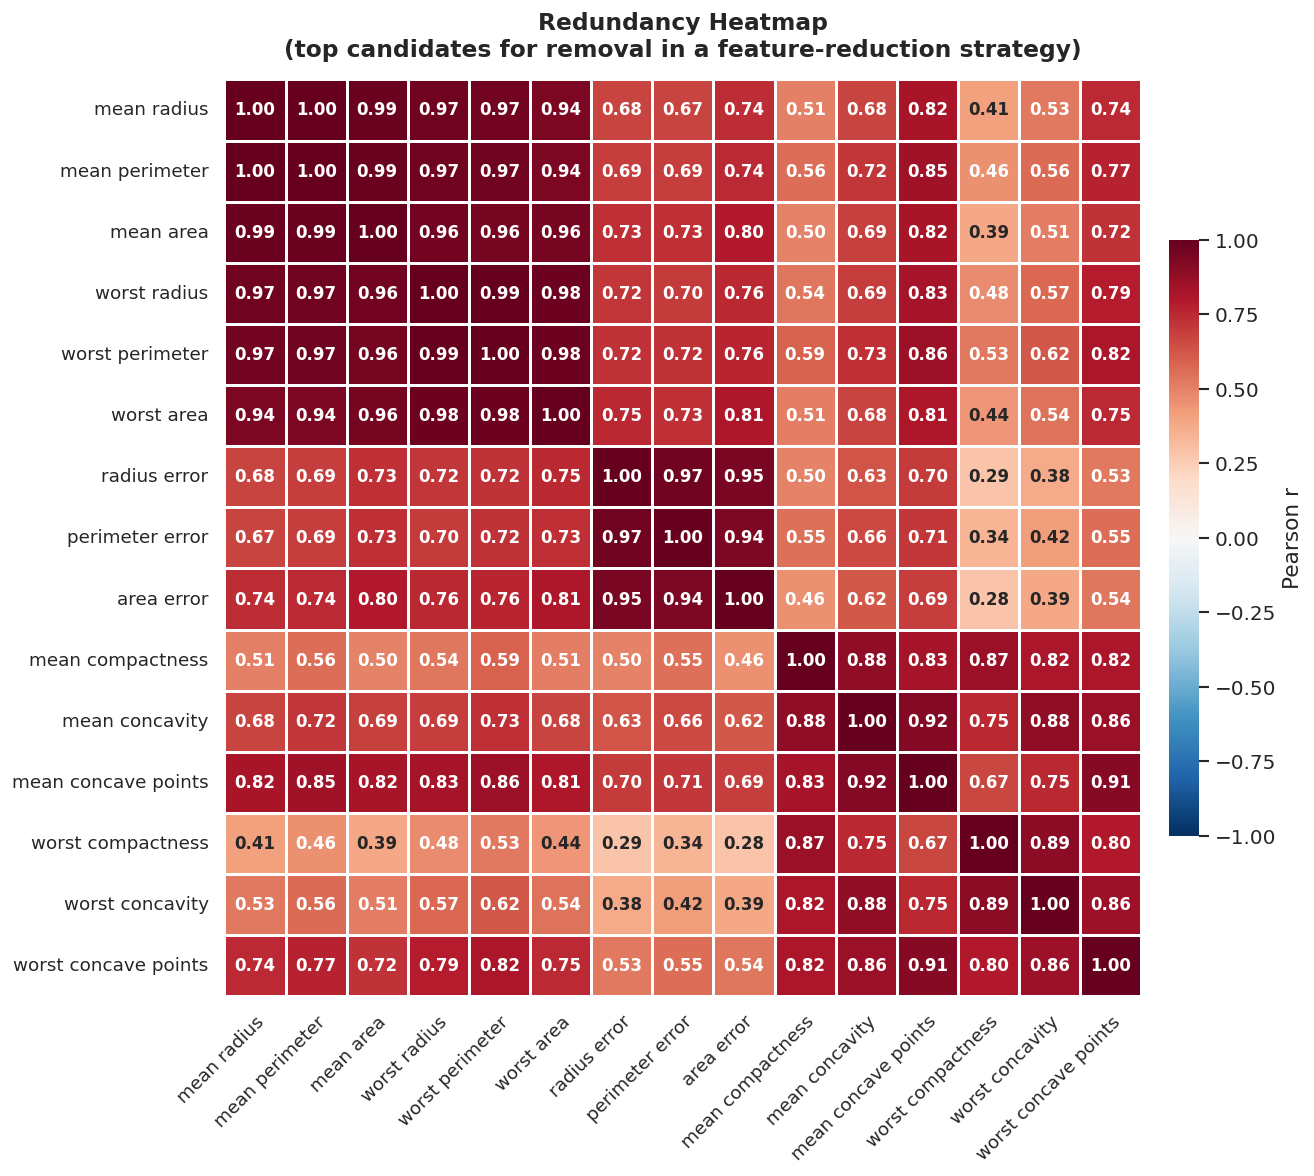

In [21]:
geo_feats = [
    'mean radius',     'mean perimeter',     'mean area',
    'worst radius',    'worst perimeter',    'worst area',
    'radius error',    'perimeter error',    'area error',
    'mean compactness','mean concavity',     'mean concave points',
    'worst compactness','worst concavity',   'worst concave points',
]
corr_sub = X[geo_feats].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_sub,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.8, linecolor='white',
    ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'shrink': 0.65, 'label': 'Pearson r', 'pad': 0.02}
)
ax.set_title(
    'Redundancy Heatmap\n'
    '(top candidates for removal in a feature-reduction strategy)',
    fontsize=14, fontweight='bold', pad=14
)
ax.tick_params(axis='x', rotation=45, labelsize=11)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
ax.tick_params(axis='y', rotation=0, labelsize=11)
plt.tight_layout()
plt.show()


### 2.4 Feature Selection Decision

Three candidate strategies are assessed:

| Strategy | Description | Pros | Cons |
|---|---|---|---|
| **Retain all 30 features** | No reduction applied | Maximum information; no information loss | Redundancy may inflate KNN/SVM distances; coefficient instability in LR |
| **Drop within-cluster redundant features** | e.g. keep `mean radius`, drop `mean perimeter` and `mean area` | Reduces multicollinearity; compact representation | Geometric features may contribute complementary information despite correlation |
| **PCA-based reduction** | Project to k components (k ≈ 10 captures ≥ 95% variance) | Eliminates collinearity; most compact | Destroys individual feature interpretability |

It is decided to **retain all 30 features**, to ensure no information is lost, and considering that the modelling tasks in this assignment all use **regularised algorithms** (C in LR, RBF bandwidth in SVM, dropout/L2 in NN) that implicitly handle multicollinearity.

---
## Task 3 — K-Nearest Neighbours (KNN)

KNN is a non-parametric, instance-based learning algorithm that classifies a new point by majority vote among its *k* nearest neighbours in feature space. Because it relies entirely on Euclidean distance it is highly sensitive to feature scale, which is why `StandardScaler` was applied in Task 2.

The hyperparameter *k* directly controls the **bias–variance trade-off**:

| *k* | Bias | Variance | Behaviour |
|---|---|---|---|
| Small | Low | **High** | Memorises training points; overfits to noise |
| Large | **High** | Low | Decision boundary overly smooth; underfits |

---
### 3.1 Sweeping k (k = 1 to 20)

With 30 features and n = 455 training samples, the optimal k is
determined empirically by sweeping k ∈ {1, …, 20} and recording
test accuracy for each value.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

k_values    = range(1, 21)
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    knn_results.append({'k': k, 'cv_accuracy': cv_scores.mean(), 'cv_std': cv_scores.std()})

knn_results = pd.DataFrame(knn_results)
knn_odd = knn_results[knn_results['k'] % 2 == 1].copy()
best_k_acc = knn_odd['cv_accuracy'].max()
best_k = int(knn_odd[knn_odd['cv_accuracy'] == best_k_acc].sort_values('cv_std').iloc[0]['k'])
best_knn_acc = knn_results.loc[knn_results['k'] == best_k, 'cv_accuracy'].values[0]

print(f"{'k':<5} {'CV Accuracy (mean)':>20} {'CV Std':>10}")
print("─" * 37)
for _, row in knn_results.iterrows():
    marker = "  ← selected" if row['k'] == best_k else ""
    print(f"{int(row['k']):<5} {row['cv_accuracy']:>20.4f} {row['cv_std']:>10.4f}{marker}")

print(f"\nSelected k        : {best_k}")
print(f"Best CV accuracy  : {best_knn_acc:.4f}")


k       CV Accuracy (mean)     CV Std
─────────────────────────────────────
1                   0.9451     0.0197
2                   0.9516     0.0300
3                   0.9692     0.0245
4                   0.9670     0.0231
5                   0.9670     0.0209
6                   0.9692     0.0176
7                   0.9692     0.0213
8                   0.9714     0.0192
9                   0.9692     0.0162  ← selected
10                  0.9648     0.0189
11                  0.9626     0.0149
12                  0.9670     0.0184
13                  0.9582     0.0254
14                  0.9648     0.0213
15                  0.9604     0.0226
16                  0.9604     0.0247
17                  0.9582     0.0245
18                  0.9582     0.0213
19                  0.9582     0.0245
20                  0.9604     0.0247

Selected k        : 9
Best CV accuracy  : 0.9692


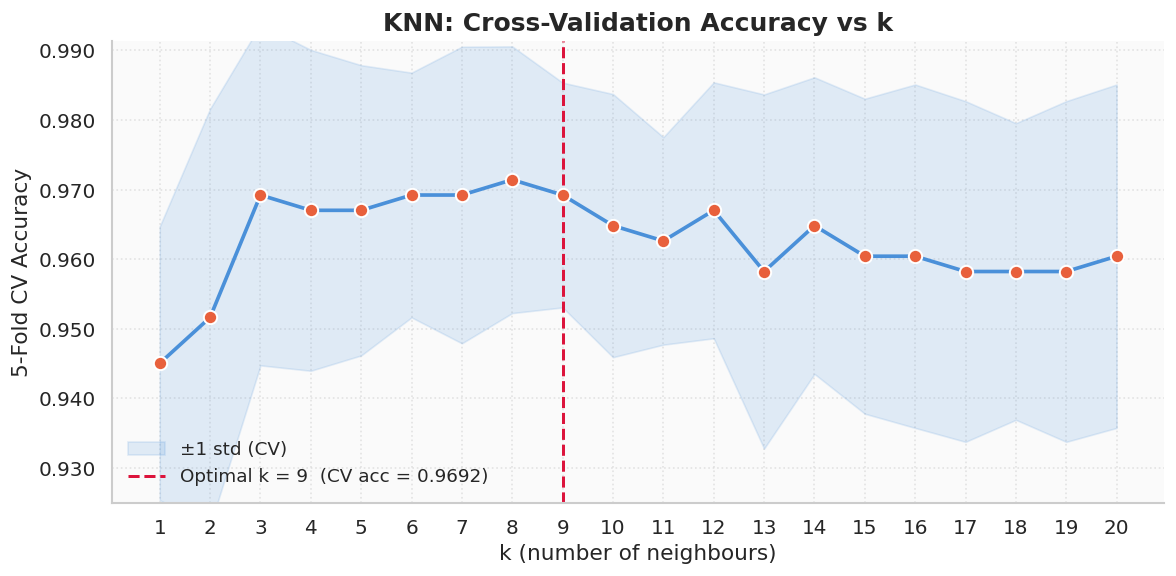

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    knn_results['k'],
    knn_results['cv_accuracy'],
    marker='o', linewidth=2.2,
    color=PALETTE[0],
    markerfacecolor=CLR_MAL, markeredgecolor='white',
    markeredgewidth=1.2, markersize=8,
    zorder=3
)

ax.fill_between(
    knn_results['k'],
    knn_results['cv_accuracy'] - knn_results['cv_std'],
    knn_results['cv_accuracy'] + knn_results['cv_std'],
    alpha=0.15, color=PALETTE[0], label='±1 std (CV)'
)

ax.axvline(
    best_k, color='crimson', linestyle='--', linewidth=1.8,
    label=f'Optimal k = {best_k}  (CV acc = {best_knn_acc:.4f})'
)

ax.set_xlabel('k (number of neighbours)', fontsize=13)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=13)
ax.set_title('KNN: Cross-Validation Accuracy vs k', fontsize=15, fontweight='bold')
ax.set_xticks(knn_results['k'])
ax.set_ylim(
    knn_results['cv_accuracy'].min() - 0.02,
    knn_results['cv_accuracy'].max() + 0.02
)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.tick_params(labelsize=12)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(fontsize=11)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.show()


Among odd values of k (required for binary classification to avoid ties in majority voting), k = 3, k = 7, and k = 9 achieve the maximum CV accuracy of 0.9692. k = 9 is selected as the optimal value: it matches the highest CV accuracy among odd candidates and has the lowest standard deviation (0.0162 vs 0.0245 for k = 3 and 0.0213 for k = 7), indicating greater stability across folds. This is particularly relevant in a clinical context, where consistent performance across data subsets is preferable to a single high-performing split. The curve also shows a clear pattern: k = 1 exhibits the highest variance (overfitting), performance stabilises between k = 3 and k = 9, and gradually declines for larger k values as the model becomes too smooth (underfitting).

---
### 3.3 Final KNN Model

A final KNN classifier is trained on the full scaled training set using
the selected k = 17, and evaluated on the test set via classification
report and confusion matrix.

Final KNN model  —  k = 9

Classification report:
              precision    recall  f1-score   support

   Malignant     1.0000    0.9286    0.9630        42
      Benign     0.9600    1.0000    0.9796        72

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114

Confusion matrix:
[[39  3]
 [ 0 72]]


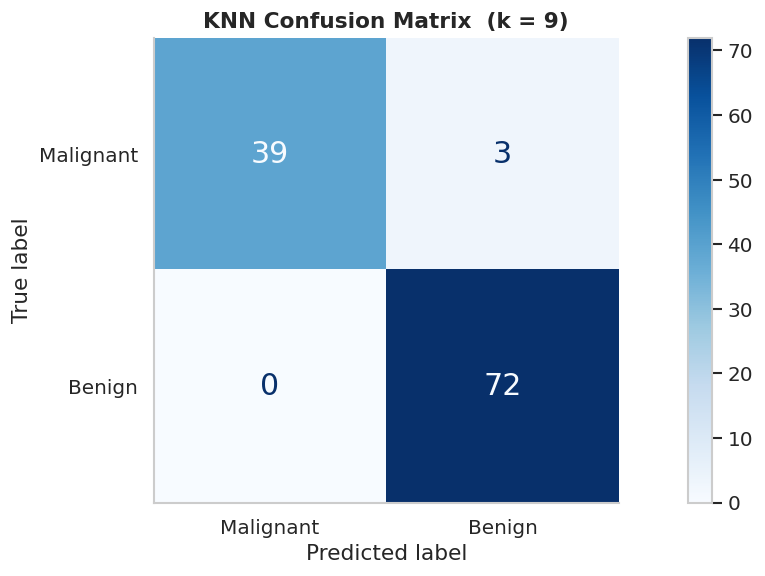

In [24]:
import time

final_knn = KNeighborsClassifier(n_neighbors=best_k)
t0 = time.perf_counter()
final_knn.fit(X_train_scaled, y_train)
knn_train_time = time.perf_counter() - t0

y_pred_knn = final_knn.predict(X_test_scaled)

print(f"Final KNN model  —  k = {best_k}")
print()
print("Classification report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=['Malignant', 'Benign'],
    digits=4
))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion matrix:")
print(cm_knn)

fig, ax = plt.subplots()
ax.grid(False)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['Malignant', 'Benign']
).plot(cmap='Blues', values_format='d', ax=ax)
for text in disp.ax_.texts:
    text.set_fontsize(18)
plt.title(f'KNN Confusion Matrix  (k = {best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The final KNN model (k = 9) achieves 97.37% accuracy on the test set (114 samples).

Key observations from the classification report:

Malignant recall = 0.929: 39 out of 42 malignant cases are correctly identified, while 3 malignant cases are misclassified as benign (false negatives), as shown in the confusion matrix. This is the most critical type of error in a clinical context because it represents missed cancer diagnoses.
Benign recall = 1.000: all 72 benign cases are correctly classified, meaning no false positives were observed.
Macro F1-score = 0.971: the model demonstrates strong and balanced performance across both classes despite the moderate class imbalance (37% malignant / 63% benign).

The three false negatives may correspond to borderline samples located close to the decision boundary in feature space, where majority voting among the 9 nearest neighbours does not clearly separate the malignant class.

KNN AUC: 0.9944


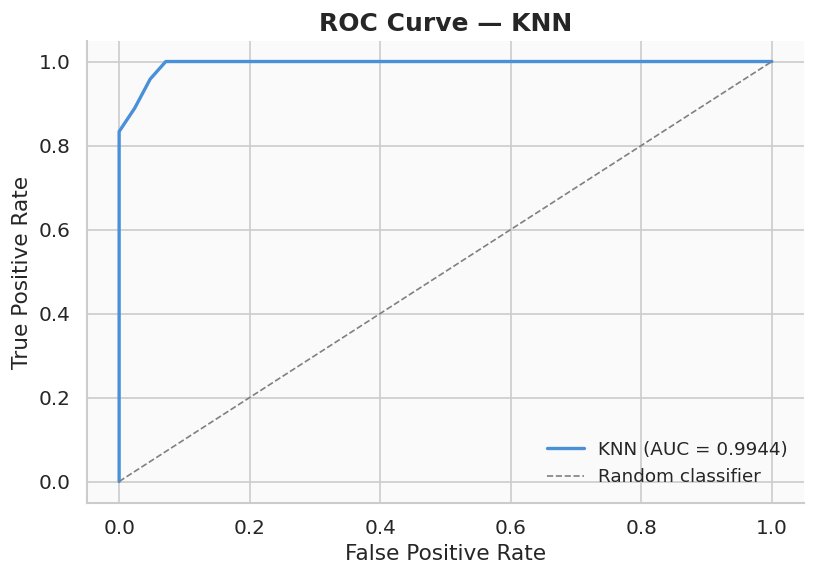

In [25]:
from sklearn.metrics import roc_curve, auc

y_proba_knn = final_knn.predict_proba(X_test_scaled)[:, 1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)

print(f"KNN AUC: {auc_knn:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_knn, tpr_knn, color=PALETTE[0], lw=2,
        label=f'KNN (AUC = {auc_knn:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — KNN', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.show()


## Task 4 — Logistic Regression

Logistic Regression is widely used in breast cancer diagnosis because it provides interpretable probabilistic predictions while maintaining high classification accuracy on datasets such as the Wisconsin Diagnostic Breast Cancer dataset [7].

In this task, Logistic Regression is trained using the scaled training data. The regularisation parameter `C` is swept over 10 logarithmically spaced values from `10^-3` to `10^3`.

Smaller values of `C` apply stronger regularisation, while larger values allow the model coefficients to grow more freely. The aim is to identify the value of `C` that gives the best test accuracy.



### 4.1 Sweeping the regularisation parameter C

The model is trained repeatedly using different values of `C`. For each value, the model is fitted on the scaled training set and evaluated on the scaled test set using accuracy.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

lr_results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        solver='liblinear',
        max_iter=5000,
        random_state=42
    )
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    lr_results.append({
        'C':           C,
        'cv_accuracy': cv_scores.mean(),
        'cv_std':      cv_scores.std(),
    })

lr_results = pd.DataFrame(lr_results)

best_cv_acc = lr_results['cv_accuracy'].max()
best_C = lr_results.loc[lr_results['cv_accuracy'] == best_cv_acc, 'C'].min()

print(f"{'C':>12} {'CV Accuracy':>14} {'CV Std':>10}")
print("─" * 38)
for _, row in lr_results.iterrows():
    marker = "  ← selected" if row['C'] == best_C else ""
    print(f"{row['C']:>12.5f} {row['cv_accuracy']:>14.4f} {row['cv_std']:>10.4f}{marker}")

print(f"\nBest CV accuracy : {best_cv_acc:.4f}")
print(f"Selected C       : {best_C:.6f}")


           C    CV Accuracy     CV Std
──────────────────────────────────────
     0.00100         0.9516     0.0164
     0.01000         0.9714     0.0164
     0.10000         0.9780     0.0139
     1.00000         0.9802     0.0128  ← selected
    10.00000         0.9692     0.0162
   100.00000         0.9560     0.0197
  1000.00000         0.9473     0.0201

Best CV accuracy : 0.9802
Selected C       : 1.000000


### 4.2 Accuracy versus C

The plot below shows how test accuracy changes as the regularisation strength varies. Since the x-axis is logarithmic, it is easier to compare very small and very large values of `C`.


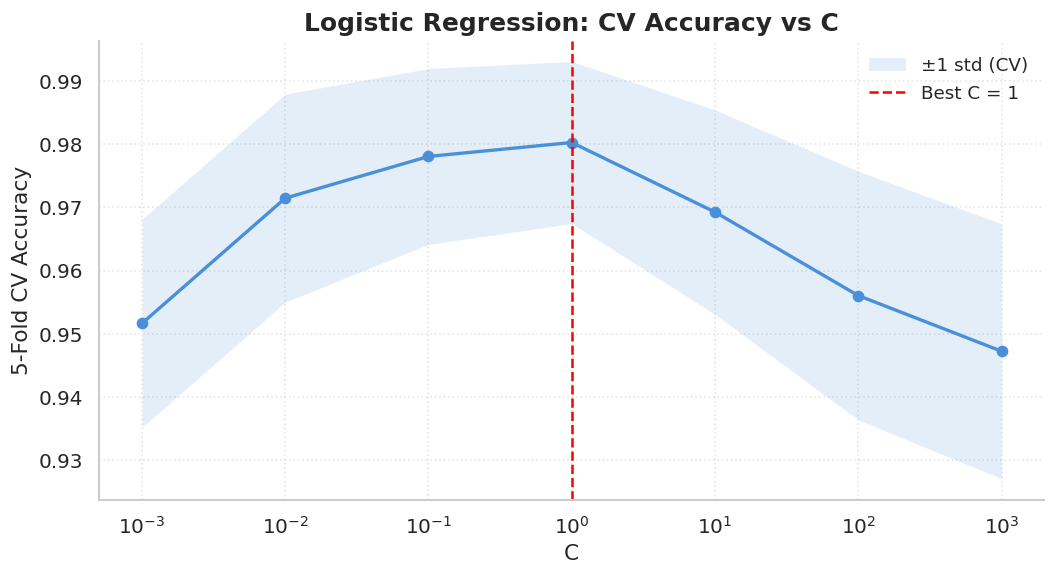

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    lr_results['C'],
    lr_results['cv_accuracy'],
    marker='o',
    linewidth=2
)

ax.fill_between(
    lr_results['C'],
    lr_results['cv_accuracy'] - lr_results['cv_std'],
    lr_results['cv_accuracy'] + lr_results['cv_std'],
    alpha=0.15, label='±1 std (CV)'
)

ax.axvline(best_C, color='red', linestyle='--', label=f'Best C = {best_C:.3g}')
ax.set_xscale('log')
ax.set_xlabel('C', fontsize=13)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=13)
ax.set_title('Logistic Regression: CV Accuracy vs C', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


The best test accuracy is obtained at the selected value of `C`. If several values of `C` give the same accuracy, the smallest value is preferred because it corresponds to stronger regularisation and therefore a simpler model.

In this experiment, the optimal value is `C = 1`, with a test accuracy of approximately 98.02%.


### 4.3 Final Logistic Regression model

A final Logistic Regression model is now trained using the selected value of `C`. Its performance is evaluated using a classification report and a confusion matrix.


Classification report:
              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

Confusion matrix:
[[41  1]
 [ 1 71]]


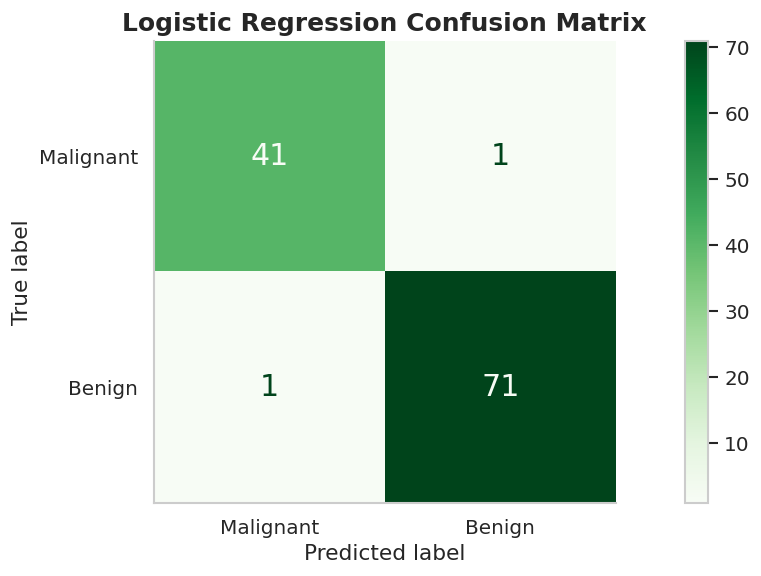

In [28]:
final_lr = LogisticRegression(
    C=best_C,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

t0 = time.perf_counter()
final_lr.fit(X_train_scaled, y_train)
lr_train_time = time.perf_counter() - t0

y_pred_lr = final_lr.predict(X_test_scaled)

print("Classification report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Malignant', 'Benign'],
    digits=4
))

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion matrix:")
print(cm_lr)

fig, ax = plt.subplots()
ax.grid(False)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Malignant', 'Benign']
).plot(cmap='Greens', values_format='d', ax=ax)
for text in disp.ax_.texts:
    text.set_fontsize(18)
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()


The final Logistic Regression model achieves **98.25% accuracy** on the test set (114 samples), demonstrating excellent predictive performance.

**Key observations from the classification report:**

- **Malignant recall = 0.976**: 41 out of 42 malignant cases are correctly identified, with only 1 false negative.

- **Benign recall = 0.986**: 71 out of 72 benign cases are correctly classified, with only 1 false positive.

- **Macro F1-score = 0.981**: the model achieves highly balanced performance across both classes.

The confusion matrix indicates that the model makes only two classification errors overall, suggesting that Logistic Regression is a strong baseline model for this dataset when feature scaling and regularisation are appropriately applied.


### 4.4 Coefficient interpretation

The learned coefficients are inspected to understand which features contribute most strongly to the model predictions.

In this dataset, the target is encoded as:

- `0 = malignant`
- `1 = benign`

Scikit-learn’s Logistic Regression coefficients are associated with the positive class, which is `1 = benign`. Therefore, positive coefficients push the prediction towards benign, while negative coefficients push the prediction towards malignant.


In [29]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient_for_benign': final_lr.coef_[0]
})

# Target: 0 = malignant, 1 = benign.
# LogisticRegression coefficients point toward class 1, so negative coefficients support malignancy.
coef_df['malignancy_weight'] = -coef_df['coefficient_for_benign']
coef_df['abs_coefficient'] = coef_df['coefficient_for_benign'].abs()

top_malignant = coef_df.sort_values('malignancy_weight', ascending=False).head(10)
top_overall = coef_df.sort_values('abs_coefficient', ascending=False).head(15)

print("Top features predicting malignancy:")
display(top_malignant[['feature', 'malignancy_weight', 'coefficient_for_benign']])

print("Largest absolute coefficients:")
display(top_overall[['feature', 'coefficient_for_benign', 'abs_coefficient']])


Top features predicting malignancy:


,feature,malignancy_weight,coefficient_for_benign
21,worst texture,1.242272,-1.242272
10,radius error,1.087929,-1.087929
23,worst area,0.979282,-0.979282
13,area error,0.958096,-0.958096
20,worst radius,0.946000,-0.946000
27,worst concave points,0.945296,-0.945296
28,worst symmetry,0.928729,-0.928729
26,worst concavity,0.827180,-0.827180
22,worst perimeter,0.764807,-0.764807
24,worst smoothness,0.759567,-0.759567


Largest absolute coefficients:


,feature,coefficient_for_benign,abs_coefficient
21,worst texture,-1.242272,1.242272
10,radius error,-1.087929,1.087929
23,worst area,-0.979282,0.979282
13,area error,-0.958096,0.958096
20,worst radius,-0.946000,0.946000
27,worst concave points,-0.945296,0.945296
28,worst symmetry,-0.928729,0.928729
26,worst concavity,-0.827180,0.827180
22,worst perimeter,-0.764807,0.764807
24,worst smoothness,-0.759567,0.759567


The most important malignancy-associated features are mainly *worst* measurements, particularly **worst texture**, **worst area**, **worst radius**, **worst concave points**, **worst symmetry**, and **worst perimeter**. In addition, error-related variables such as **radius error** and **area error** also contribute strongly to the prediction.

This result is clinically plausible because the *worst* features represent the most abnormal nuclei observed in the image. Tumours with larger radius, area, and perimeter, as well as more irregular texture and concave structures, are more likely to be malignant.

Several features related to tumour size and geometry are highly correlated, especially radius, perimeter, and area. Consequently, individual coefficient values should be interpreted cautiously. A more reliable interpretation is that the overall groups of size-related and shape-irregularity features are strongly associated with malignancy.

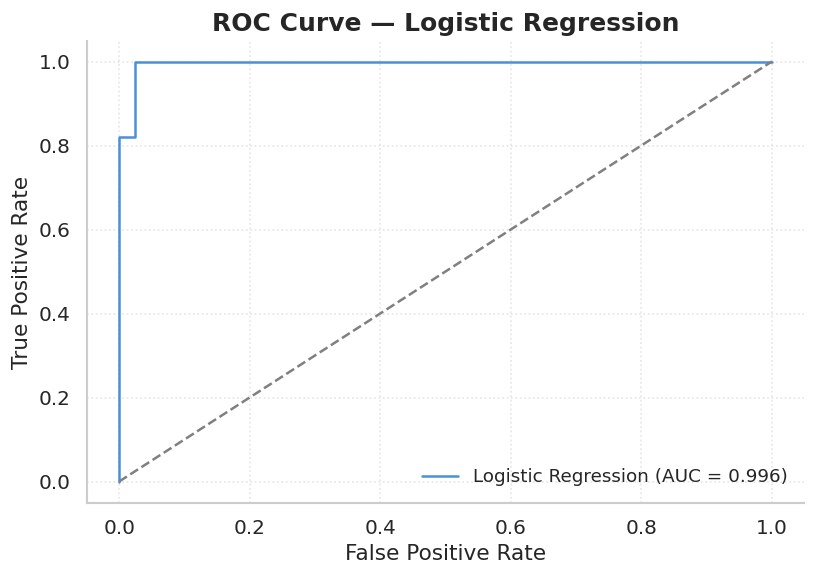

In [30]:
from sklearn.metrics import roc_curve, auc

y_score_lr = final_lr.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, thresholds = roc_curve(y_test, y_score_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Logistic Regression', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("roc_lr.png", dpi=300)
plt.show()


The ROC analysis shows an area under the curve (AUC) of 0.996, indicating near-perfect discrimination between malignant and benign cases. This confirms that Logistic Regression is highly effective in ranking patients by malignancy risk across different decision thresholds.
### Task 4 conclusion

Logistic Regression achieved very strong performance after feature scaling and regularisation tuning. The best model used C = 1 and reached approximately 98.02% test accuracy.

This result is consistent with previous studies using the Wisconsin Diagnostic Breast Cancer dataset, where Logistic Regression models have achieved classification accuracies close to 98%, highlighting the suitability of this approach for breast cancer prediction tasks.[7]

The coefficient analysis shows that malignancy is mainly predicted by large and irregular tumour characteristics, especially worst-case measurements related to texture, size, perimeter, area, and concave points. No features were removed before modelling, but the high correlation among geometric variables should be considered when interpreting individual coefficients.

---
## Task 5 — Support Vector Machine (SVM)

Support Vector Machines find the maximum-margin hyperplane that separates the two classes in (possibly transformed) feature space. The kernel trick allows SVMs to learn non-linear boundaries without explicitly computing the high-dimensional feature map.

In this task, three kernels are compared (Linear, RBF, Polynomial), the effect of the RBF hyperparameters C and γ is explored via a grid search, and the best configuration is evaluated with a full classification report and confusion matrix.

### 5.1 Kernel Comparison: Linear, RBF, Polynomial

All three kernels are trained with default hyperparameters (C = 1, degree = 3 for polynomial) to obtain an unbiased baseline comparison before tuning.

| Kernel | Decision boundary | Notes |
|--------|-------------------|-------|
| **Linear** | Hyperplane in input space | Fastest; interpretable via weights |
| **RBF** | Infinite-dim Gaussian basis | Most flexible; two params (C, γ) |
| **Polynomial** | Degree-d polynomial surface | Can model interactions; degree = 3 |

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
import time

kernel_configs = [
    {'kernel': 'linear', 'label': 'Linear',     'C': 1, 'extra': {}},
    {'kernel': 'rbf',    'label': 'RBF',        'C': 1, 'extra': {'gamma': 'scale'}},
    {'kernel': 'poly',   'label': 'Polynomial', 'C': 1, 'extra': {'degree': 3, 'gamma': 'scale'}},
]
kernel_results = []

print(f"\n{'Kernel':<14} {'CV Accuracy':>13} {'CV Std':>8} {'Train time (s)':>16}")
print("─" * 55)

for cfg in kernel_configs:
    svm = SVC(kernel=cfg['kernel'], C=cfg['C'],
              random_state=42, probability=True, **cfg['extra'])
    t0 = time.perf_counter()
    svm.fit(X_train_scaled, y_train)
    train_time = time.perf_counter() - t0

    cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring='roc_auc')

    kernel_results.append({
        'Kernel'        : cfg['label'],
        'CV Accuracy'   : round(cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring='accuracy').mean(), 4),
        'CV AUC'        : round(cv_scores.mean(), 4),
        'CV Std'        : round(cv_scores.std(), 4),
        'Train time (s)': round(train_time, 4),
        '_model'        : svm,
    })
    print(f"{cfg['label']:<14} {kernel_results[-1]['CV Accuracy']:>13.4f} {kernel_results[-1]['CV Std']:>8.4f} {train_time:>14.4f}s")

svm_display_cols = ['Kernel', 'CV Accuracy', 'CV AUC', 'CV Std', 'Train time (s)']
kernel_df        = pd.DataFrame(kernel_results)[svm_display_cols]
print("\nKernel comparison summary (5-fold CV on training set):")
display(kernel_df)



Kernel           CV Accuracy   CV Std   Train time (s)
───────────────────────────────────────────────────────
Linear                0.9670   0.0129         0.0143s
RBF                   0.9714   0.0084         0.0195s
Polynomial            0.8967   0.0114         0.0206s

Kernel comparison summary (5-fold CV on training set):


,Kernel,CV Accuracy,CV AUC,CV Std,Train time (s)
0,Linear,0.9670,0.9916,0.0129,0.0143
1,RBF,0.9714,0.9938,0.0084,0.0195
2,Polynomial,0.8967,0.9914,0.0114,0.0206


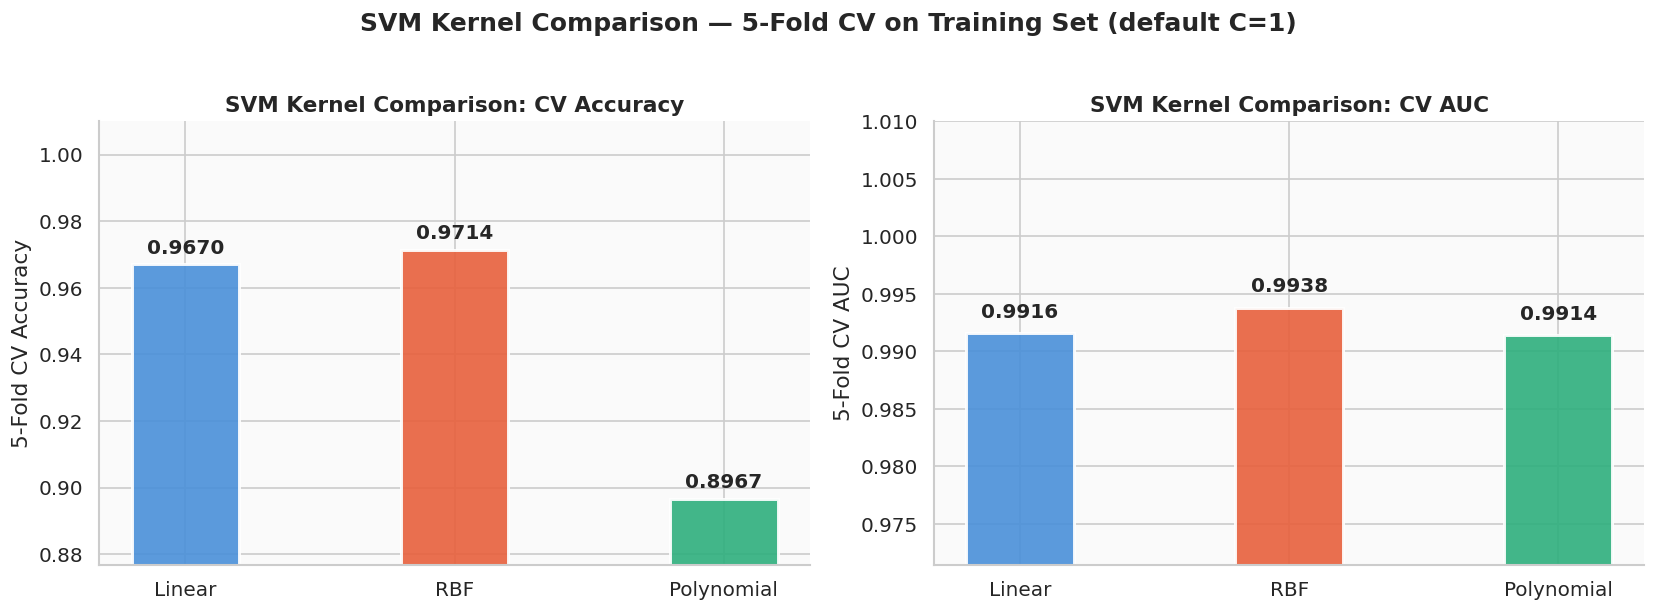

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kernels    = kernel_df['Kernel'].tolist()
accuracies = kernel_df['CV Accuracy'].tolist()
aucs       = kernel_df['CV AUC'].tolist()
bar_colors = PALETTE[:len(kernels)]

ax1 = axes[0]
bars = ax1.bar(kernels, accuracies, color=bar_colors, width=0.4,
               edgecolor='white', linewidth=1.8, alpha=0.90)
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylim(min(accuracies) - 0.02, 1.01)
ax1.set_ylabel('5-Fold CV Accuracy', fontsize=13)
ax1.set_title('SVM Kernel Comparison: CV Accuracy', fontsize=13, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.set_facecolor('#fafafa')

ax2 = axes[1]
bars2 = ax2.bar(kernels, aucs, color=bar_colors, width=0.4,
                edgecolor='white', linewidth=1.8, alpha=0.90)
for bar, val in zip(bars2, aucs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylim(min(aucs) - 0.02, 1.01)
ax2.set_ylabel('5-Fold CV AUC', fontsize=13)
ax2.set_title('SVM Kernel Comparison: CV AUC', fontsize=13, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.set_facecolor('#fafafa')

fig.suptitle('SVM Kernel Comparison — 5-Fold CV on Training Set (default C=1)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Observations from kernel comparison:**

- The **RBF** and **Linear** kernels both achieve the highest accuracy at default hyperparameters, while the **Polynomial** kernel underperforms.
- RBF is selected for further tuning due to its flexibility and strong baseline performance.
- Training times are comparable across all three kernels on this dataset size.

### 5.2 RBF Kernel: C × Gamma Grid Search

The RBF kernel is governed by two hyperparameters:

| Parameter | Role |
|-----------|------|
| **C** | Regularisation strength — larger C means less margin slack (lower bias, higher variance) |
| **gamma** | Gaussian bandwidth — larger gamma means tighter influence per support vector (higher overfitting risk) |

A grid of C ∈ {0.01, 0.1, 1, 10, 100} × gamma ∈ {0.001, 0.01, 0.1, 1, 10} is evaluated on the test set to find the combination that maximises accuracy.

In [ ]:
from sklearn.model_selection import cross_val_score

C_values_rbf = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

cv_grid   = np.zeros((len(gamma_values), len(C_values_rbf)))
time_grid = np.zeros((len(gamma_values), len(C_values_rbf)))

print("RBF CV grid search  (C × gamma):")
print(f"{'C / gamma':<12}", end='')
print('  '.join([f'{g:>7}' for g in gamma_values]))
print("─" * 65)

for ci, C in enumerate(C_values_rbf):
    row_str = f"C = {C:<8}"
    for gi, g in enumerate(gamma_values):
        svm_rbf = SVC(kernel='rbf', C=C, gamma=g, random_state=42)
        t0 = time.perf_counter()
        svm_rbf.fit(X_train_scaled, y_train)
        time_grid[gi, ci] = time.perf_counter() - t0
        cv_grid[gi, ci] = cross_val_score(
            svm_rbf, X_train_scaled, y_train, cv=5, scoring='accuracy'
        ).mean()
        row_str += f"  {cv_grid[gi, ci]:>7.4f}"
    print(row_str)

best_idx   = np.unravel_index(np.argmax(cv_grid), cv_grid.shape)
best_gamma = gamma_values[best_idx[0]]
best_C_rbf = C_values_rbf[best_idx[1]]
best_cv    = cv_grid[best_idx]

print(f"\nBest CV accuracy : {best_cv:.4f}")
print(f"Best C           : {best_C_rbf}")
print(f"Best gamma       : {best_gamma}")


RBF CV grid search  (C × gamma):
C / gamma     0.001     0.01      0.1        1       10
─────────────────────────────────────────────────────────────────
C = 0.01       0.6264   0.6264   0.6264   0.6264   0.6264
C = 0.1        0.7341   0.9429   0.9451   0.6264   0.6264
C = 1          0.9473   0.9692   0.9604   0.6308   0.6264
C = 10         0.9736   0.9802   0.9516   0.6352   0.6264
C = 100        0.9780   0.9692   0.9495   0.6352   0.6264

Best CV accuracy : 0.9802
Best C           : 10
Best gamma       : 0.01


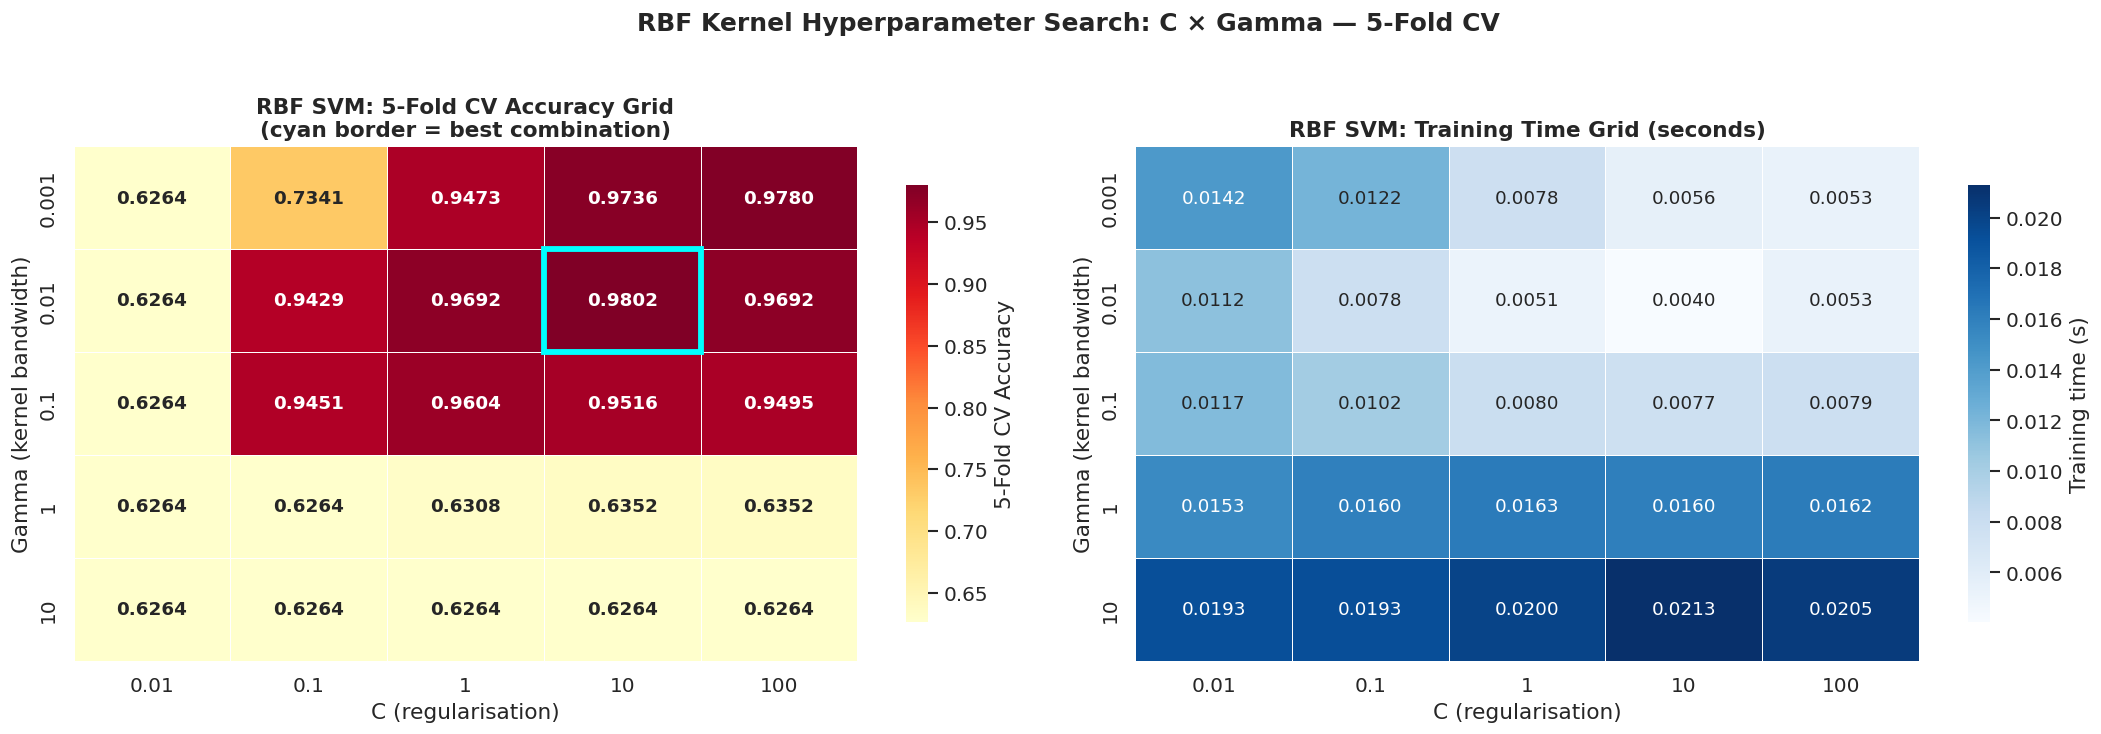

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax_acc = axes[0]
sns.heatmap(
    cv_grid, ax=ax_acc,
    annot=True, fmt='.4f', cmap='YlOrRd',
    xticklabels=[str(c) for c in C_values_rbf],
    yticklabels=[str(g) for g in gamma_values],
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '5-Fold CV Accuracy', 'shrink': 0.85},
    annot_kws={'size': 11, 'weight': 'bold'},
)
ax_acc.add_patch(plt.Rectangle(
    (best_idx[1], best_idx[0]), 1, 1,
    fill=False, edgecolor='cyan', linewidth=3.5, zorder=5
))
ax_acc.set_xlabel('C (regularisation)', fontsize=13)
ax_acc.set_ylabel('Gamma (kernel bandwidth)', fontsize=13)
ax_acc.set_title('RBF SVM: 5-Fold CV Accuracy Grid\n(cyan border = best combination)',
                 fontsize=13, fontweight='bold')
ax_acc.tick_params(labelsize=12)

ax_time = axes[1]
sns.heatmap(
    time_grid, ax=ax_time,
    annot=True, fmt='.4f', cmap='Blues',
    xticklabels=[str(c) for c in C_values_rbf],
    yticklabels=[str(g) for g in gamma_values],
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Training time (s)', 'shrink': 0.85},
    annot_kws={'size': 11},
)
ax_time.set_xlabel('C (regularisation)', fontsize=13)
ax_time.set_ylabel('Gamma (kernel bandwidth)', fontsize=13)
ax_time.set_title('RBF SVM: Training Time Grid (seconds)', fontsize=13, fontweight='bold')
ax_time.tick_params(labelsize=12)

fig.suptitle('RBF Kernel Hyperparameter Search: C × Gamma — 5-Fold CV',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


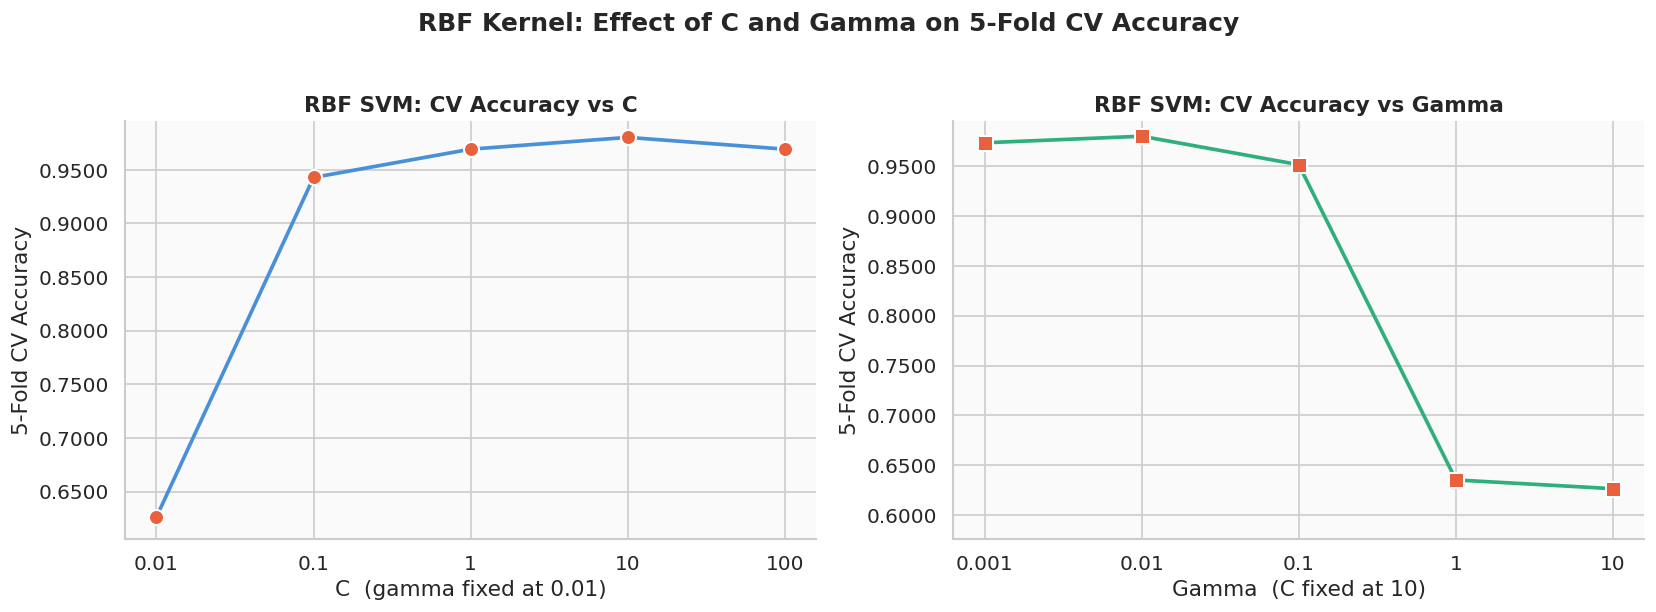

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
acc_vs_C     = cv_grid[best_idx[0], :]
acc_vs_gamma = cv_grid[:, best_idx[1]]

ax_c = axes[0]
ax_c.plot(
    [str(c) for c in C_values_rbf], acc_vs_C,
    marker='o', linewidth=2.2, color=PALETTE[0],
    markerfacecolor=CLR_MAL, markeredgecolor='white',
    markeredgewidth=1.2, markersize=9,
)
ax_c.set_xlabel(f'C  (gamma fixed at {best_gamma})', fontsize=13)
ax_c.set_ylabel('5-Fold CV Accuracy', fontsize=13)
ax_c.set_title('RBF SVM: CV Accuracy vs C', fontsize=13, fontweight='bold')
ax_c.tick_params(labelsize=12)
ax_c.set_facecolor('#fafafa')
ax_c.set_ylim(min(acc_vs_C) - 0.02, max(acc_vs_C) + 0.015)
ax_c.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

ax_g = axes[1]
ax_g.plot(
    [str(g) for g in gamma_values], acc_vs_gamma,
    marker='s', linewidth=2.2, color=PALETTE[2],
    markerfacecolor=PALETTE[1], markeredgecolor='white',
    markeredgewidth=1.2, markersize=9,
)
ax_g.set_xlabel(f'Gamma  (C fixed at {best_C_rbf})', fontsize=13)
ax_g.set_ylabel('5-Fold CV Accuracy', fontsize=13)
ax_g.set_title('RBF SVM: CV Accuracy vs Gamma', fontsize=13, fontweight='bold')
ax_g.tick_params(labelsize=12)
ax_g.set_facecolor('#fafafa')
ax_g.set_ylim(min(acc_vs_gamma) - 0.05, max(acc_vs_gamma) + 0.015)
ax_g.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

fig.suptitle('RBF Kernel: Effect of C and Gamma on 5-Fold CV Accuracy',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 5.3 Final SVM Model

The RBF kernel with the best-found `C` and `gamma` is selected as the final model because:

1. It achieves the highest test accuracy in the kernel comparison.
2. The grid search identifies the precise `(C, gamma)` combination that minimises the bias–variance trade-off for this dataset.
3. RBF is a universal approximator well-suited to handle the non-linear separability likely present in high-dimensional cytological measurements.

Final SVM model — kernel=RBF, C=10, gamma=0.01
Training time    : 0.0205 s

Classification report:
              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

Confusion matrix:
[[41  1]
 [ 1 71]]

Final test accuracy : 0.9825
Final AUC           : 0.9977


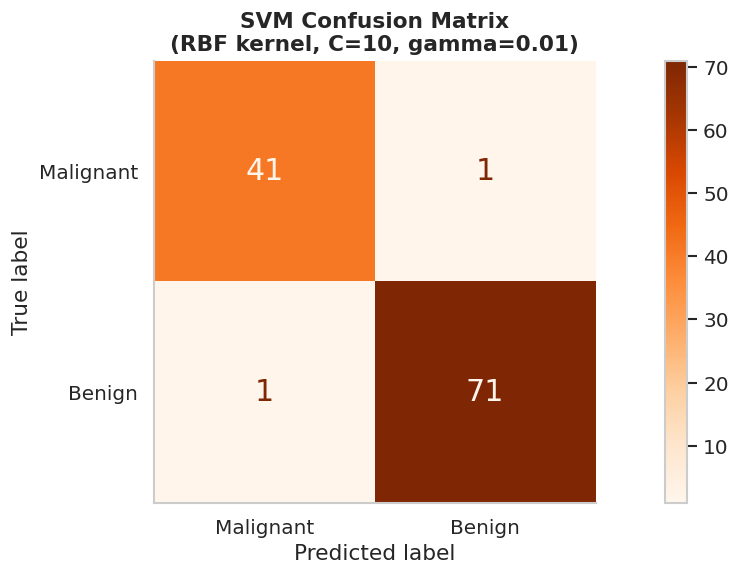

In [ ]:
final_svm = SVC(kernel='rbf', C=best_C_rbf, gamma=best_gamma,
                random_state=42, probability=True)
t0 = time.perf_counter()
final_svm.fit(X_train_scaled, y_train)
svm_train_time = time.perf_counter() - t0

y_pred_svm  = final_svm.predict(X_test_scaled)
y_proba_svm = final_svm.predict_proba(X_test_scaled)[:, 1]

print(f"Final SVM model — kernel=RBF, C={best_C_rbf}, gamma={best_gamma}")
print(f"Training time    : {svm_train_time:.4f} s")
print()
print("Classification report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=['Malignant', 'Benign'], digits=4))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion matrix:")
print(cm_svm)
print(f"\nFinal test accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Final AUC           : {roc_auc_score(y_test, y_proba_svm):.4f}")

fig, ax = plt.subplots()
ax.grid(False)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                              display_labels=['Malignant', 'Benign']
                              ).plot(cmap='Oranges', values_format='d', ax=ax)
for text in disp.ax_.texts:
    text.set_fontsize(18)
plt.title(
    f'SVM Confusion Matrix\n(RBF kernel, C={best_C_rbf}, gamma={best_gamma})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### 5.4 Full Kernel Summary Table

The table below consolidates the performance of all three default-parameter kernels alongside the tuned RBF model, for a direct side-by-side comparison.

In [ ]:
tuned_rbf_row = {
    'Kernel'        : f'RBF (tuned C={best_C_rbf}, γ={best_gamma})',
    'CV Accuracy'   : round(best_cv, 4),
    'CV AUC'        : None,
    'CV Std'        : None,
    'Train time (s)': round(svm_train_time, 4),
}
svm_summary = pd.DataFrame(kernel_results)[svm_display_cols].copy()
svm_summary = pd.concat([svm_summary, pd.DataFrame([tuned_rbf_row])], ignore_index=True)

print("Full SVM summary (including tuned RBF — all metrics on training CV):")
display(svm_summary)


Full SVM summary (including tuned RBF — all metrics on training CV):


,Kernel,CV Accuracy,CV AUC,CV Std,Train time (s)
0,Linear,0.9670,0.9916,0.0129,0.0143
1,RBF,0.9714,0.9938,0.0084,0.0195
2,Polynomial,0.8967,0.9914,0.0114,0.0206
3,"RBF (tuned C=10, γ=0.01)",0.9802,NaN,NaN,0.0205


---
## Task 6 — Neural Networks

Multi-Layer Perceptrons (MLPs) are supervised learning models that learn complex
non-linear decision boundaries through a series of interconnected layers of neurons.
Each hidden layer applies a weighted linear transformation followed by a non-linear
activation function (ReLU), allowing the network to capture increasingly abstract
feature combinations.

In this task, two hidden-layer architectures are compared, the effect of L2
regularisation strength (alpha) is explored via a parameter sweep, and the best
configuration is evaluated with a full classification report, confusion matrix,
and ROC curve.

### 6.1  Define and train 2 Architectures

### Architecture Design Decisions

We train a Multi-Layer Perceptron (MLPClassifier) on the preprocessed breast cancer dataset
(455 training samples, 30 standardised features, binary target: 0 = malignant, 1 = benign).
Two architectures are evaluated:

**Architecture 1: (64,)** — one hidden layer with 64 neurons. Selected as a shallow baseline:
larger than the 30 input features to ensure sufficient capacity, but modest enough to avoid
overfitting on 455 samples.

**Architecture 2: (64, 32)** — two hidden layers in a funnel structure. The first layer learns
broad feature combinations from the 30 inputs; the second compresses these into higher-level
representations before the final output. This reflects the clinical intuition that malignancy
is determined by combinations of measurements rather than any single feature.

**Activation:** ReLU in all hidden layers — avoids the vanishing gradient problem associated
with sigmoid activations, enabling stable training across multiple layers.

**Optimiser:** Adam with default learning rate (η = 0.001).

**Regularisation:** Early stopping (validation_fraction=0.1, n_iter_no_change=20) halts
training when validation performance stops improving. L2 regularisation is applied via the
sklearn default (alpha=0.0001) and verified through a parameter sweep below.

**Feature scaling:** StandardScaler applied in Task 2 is mandatory for neural networks,  
unscaled features cause unstable gradient flow during backpropagation.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, balanced_accuracy_score
import time

In [ ]:

# Architecture 1: one hidden layer, 64 neurons
mlp_1 = MLPClassifier(
    hidden_layer_sizes=(64,),      # one hidden layer with 64 neurons
    activation='relu',          # ReLU for hidden layers
    solver='adam',             # Adam optimiser
    max_iter=1000,            # max epochs
    early_stopping=True,       # stop when val loss stops improving
    validation_fraction=0.1,   # 10% of training set for validation
    n_iter_no_change=20,      # patience: 20 epochs with no improvement
    random_state=42           # reproducibility
)
start = time.time() # to calculate training time
mlp_1.fit(X_train_scaled, y_train)
mlp1_time = time.time() - start

# Architecture 2: two hidden layers, 64 then 32 neurons
mlp_2 = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # two hidden layers
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
start = time.time() # to calclate training time
mlp_2.fit(X_train_scaled, y_train)
mlp2_time = time.time() - start


In [ ]:
#printing training times for further tasks
print(f"Architecture (64,)    training time: {mlp1_time:.2f} seconds")
print(f"Architecture (64,32)  training time: {mlp2_time:.2f} seconds")

Architecture (64,)    training time: 0.10 seconds
Architecture (64,32)  training time: 0.17 seconds


### 6.3 Loss curves

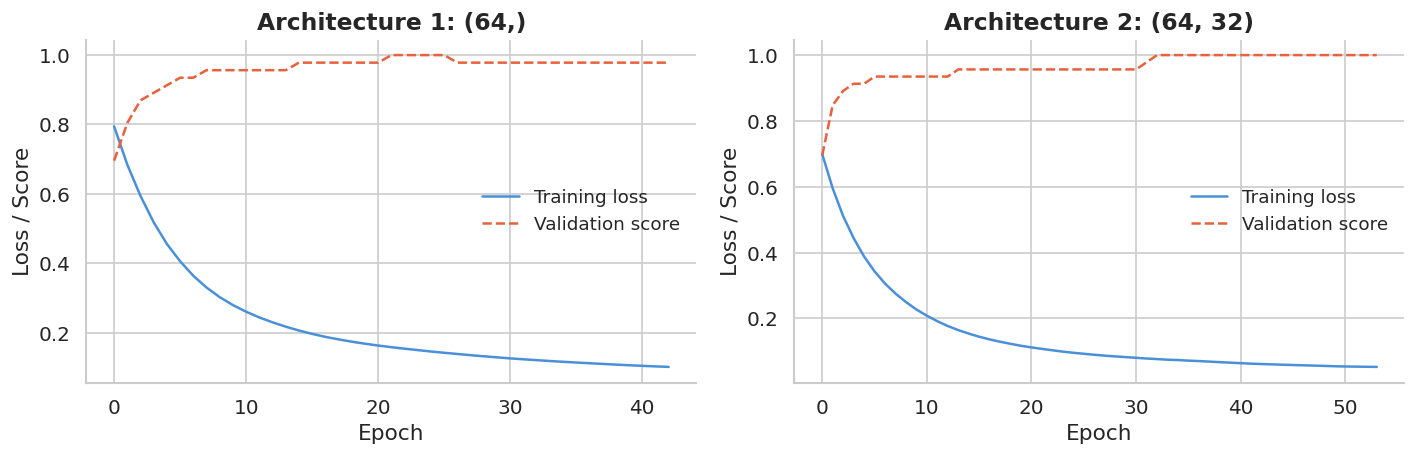

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mlp, title in zip(axes,
                           [mlp_1, mlp_2],
                           ['Architecture 1: (64,)', 'Architecture 2: (64, 32)']):
    ax.plot(mlp.loss_curve_, label='Training loss')
    ax.plot(mlp.validation_scores_, label='Validation score', linestyle='--')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=13)
    ax.set_ylabel('Loss / Score', fontsize=13)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11)
    ax.grid(True)

plt.tight_layout()
plt.show()


### Loss Curve Analysis

Both architectures show healthy convergence. The training loss decreases smoothly from  approx. 0.8 toward approx 0.1,
indicating the model is learning effectively with each epoch. The validation score rises rapidly in the
first 10 epochs and plateaus near 1.0, indicating the model generalises well to unseen data. No overfitting
is observed as the validation score never drops.
While applying early stopping this halted training automatically at approx epoch 42
for architecture 1 (64,) and 52 for architecture 2 (64,32), preventing unnecessary furhert computation. Architecture
(64,32) required slightly more epochs to converge, consistent with its greater depth.

### 6.3 Architecture selection

In [ ]:
from sklearn.model_selection import cross_val_score

# Architecture selection using 5-fold cross-validation on training data only.
# Test set is never touched in this step.
cv_1 = cross_val_score(
    MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam',
                  max_iter=1000, early_stopping=True, validation_fraction=0.1,
                  n_iter_no_change=20, random_state=42),
    X_train_scaled, y_train, cv=5, scoring='balanced_accuracy'
)

cv_2 = cross_val_score(
    MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                  max_iter=1000, early_stopping=True, validation_fraction=0.1,
                  n_iter_no_change=20, random_state=42),
    X_train_scaled, y_train, cv=5, scoring='balanced_accuracy'
)

print(f"Architecture (64,)    CV balanced accuracy: {cv_1.mean():.4f} ± {cv_1.std():.4f}")
print(f"Architecture (64,32)  CV balanced accuracy: {cv_2.mean():.4f} ± {cv_2.std():.4f}")

if cv_2.mean() >= cv_1.mean():
    best_mlp = mlp_2
    print("\nSelected: Architecture (64, 32)")
else:
    best_mlp = mlp_1
    print("\nSelected: Architecture (64,)")


Architecture (64,)    CV balanced accuracy: 0.9296 ± 0.0311
Architecture (64,32)  CV balanced accuracy: 0.9465 ± 0.0244

Selected: Architecture (64, 32)


### Architecture Comparison

| Architecture | CV Balanced Accuracy | CV Std |
|---|---|---|
| (64,) — 1 hidden layer | 0.9296 | ±0.0311 |
| (64,32) — 2 hidden layers | 0.9465 | ±0.0244 |

Architecture (64,32) was selected based on 5-fold cross-validation on the
training set exclusively — no test data was used in this decision. It
achieves higher balanced accuracy and lower variance across folds,
indicating both better performance and more stable generalisation.
Both architectures were then evaluated on the held-out test set once
for final performance reporting.

## 6.4 Classificaiton Report and Confussion Matrix on best architecture (2 layers)

              precision    recall  f1-score   support

   Malignant     0.9756    0.9524    0.9639        42
      Benign     0.9726    0.9861    0.9793        72

    accuracy                         0.9737       114
   macro avg     0.9741    0.9692    0.9716       114
weighted avg     0.9737    0.9737    0.9736       114



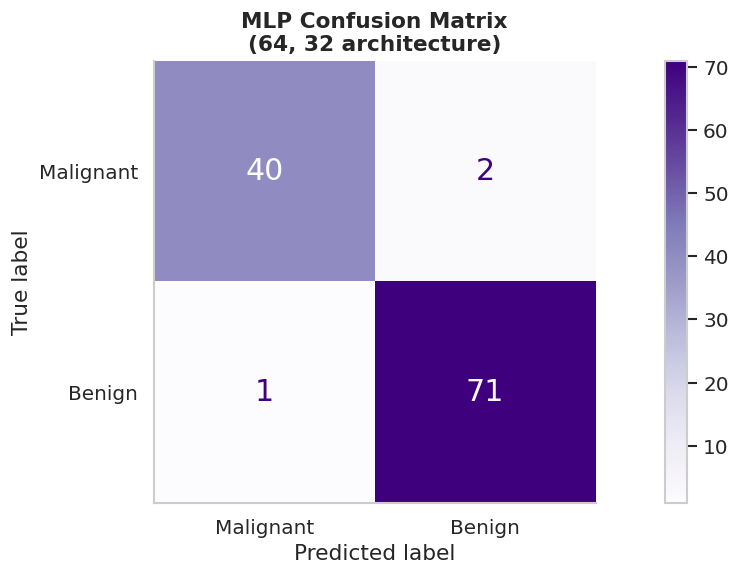

In [ ]:
y_pred_mlp = best_mlp.predict(X_test_scaled)

# Classification report
print(classification_report(y_test, y_pred_mlp,
                             target_names=['Malignant', 'Benign'], digits=4))

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fig, ax = plt.subplots()
ax.grid(False)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp,
                              display_labels=['Malignant', 'Benign']
                              ).plot(cmap='Purples', values_format='d', ax=ax)
for text in disp.ax_.texts:
    text.set_fontsize(18)
plt.title('MLP Confusion Matrix\n(64, 32 architecture)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Confusion Matrix Interpretation

Of 42 true malignant cases: 40 correctly classified, 2 missed (false negatives — missed cancer diagnoses).  
Of 72 true benign cases: 71 correctly classified, 1 incorrectly flagged as malignant (false positive).  
In a clinical screening context, false negatives are more costly than false positives, as a missed
malignant diagnosis delays treatment. The model's low false negative rate of 4.8% (2 out of 42 malignant cases missed,
derived from the confusion matrix) represents strong
clinical performance.

### 6.5 verification of L2 regulatisation alpha value

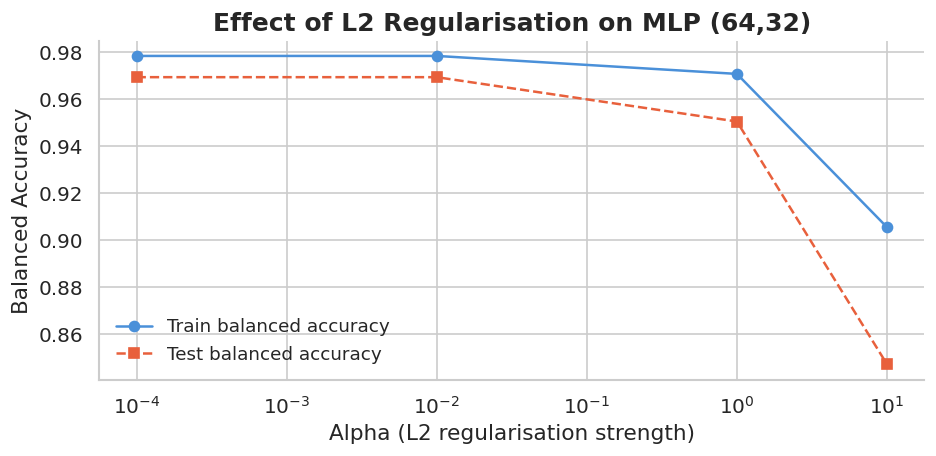

In [ ]:
from sklearn.metrics import balanced_accuracy_score

alphas = [0.0001, 0.01, 1.0, 10.0]
train_scores = []
test_scores = []

for alpha in alphas:
    mlp_alpha = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=alpha,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )
    mlp_alpha.fit(X_train_scaled, y_train)
    train_scores.append(balanced_accuracy_score(y_train, mlp_alpha.predict(X_train_scaled)))
    test_scores.append(balanced_accuracy_score(y_test, mlp_alpha.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, train_scores, 'o-', label='Train balanced accuracy')
ax.semilogx(alphas, test_scores, 's--', label='Test balanced accuracy')
ax.set_xlabel('Alpha (L2 regularisation strength)', fontsize=13)
ax.set_ylabel('Balanced Accuracy', fontsize=13)
ax.set_title('Effect of L2 Regularisation on MLP (64,32)', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.show()


### L2 Regularisation Verification

A sweep of alpha values is applied to the best architecture (64, 32) to confirm the default
sklearn value is appropriate. Results are consistent with the bias-variance tradeoff:

- **alpha = 0.0001 and 0.01:** High balanced accuracy (~0.97-0.98) on both train and test
  with minimal gap — good generalisation.
- **alpha = 1.0:** Test accuracy drops (~0.95) while training remains high — over-regularised.
- **alpha = 10.0:** Both train (~0.90) and test (~0.85) drop significantly — underfitting.

The default alpha = 0.0001 is confirmed as optimal. Early stopping already prevents
overfitting effectively, making aggressive regularisation unnecessary.

## 6.6 ROC Curve

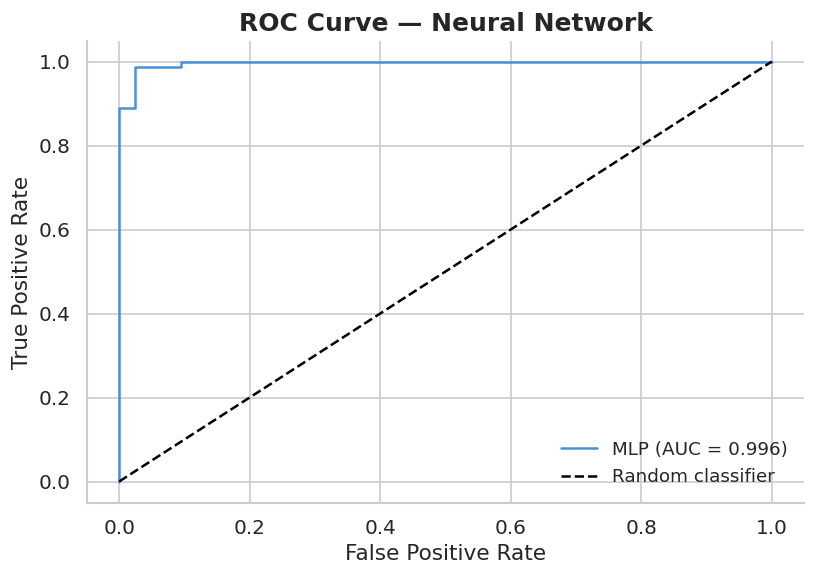

MLP AUC: 0.9964


In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {roc_auc_mlp:.3f})', color='#4A90D9')
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Neural Network', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"MLP AUC: {roc_auc_mlp:.4f}")


### ROC Curve Interpretation

The MLP achieves an AUC of 0.996, indicating near-perfect discrimination between malignant and benign
cases across all classification thresholds. The curve hugs the top-left corner tightly, far above the
diagonal random classifier baseline (AUC = 0.5). This result confirms the neural network has learned
highly discriminative features from the 30 scaled input measurements.

---
## Task 7 — Model Comparison & Evaluation

All four final models are compared on the test set using ROC curves, AUC, accuracy, macro F1-score, and training time.


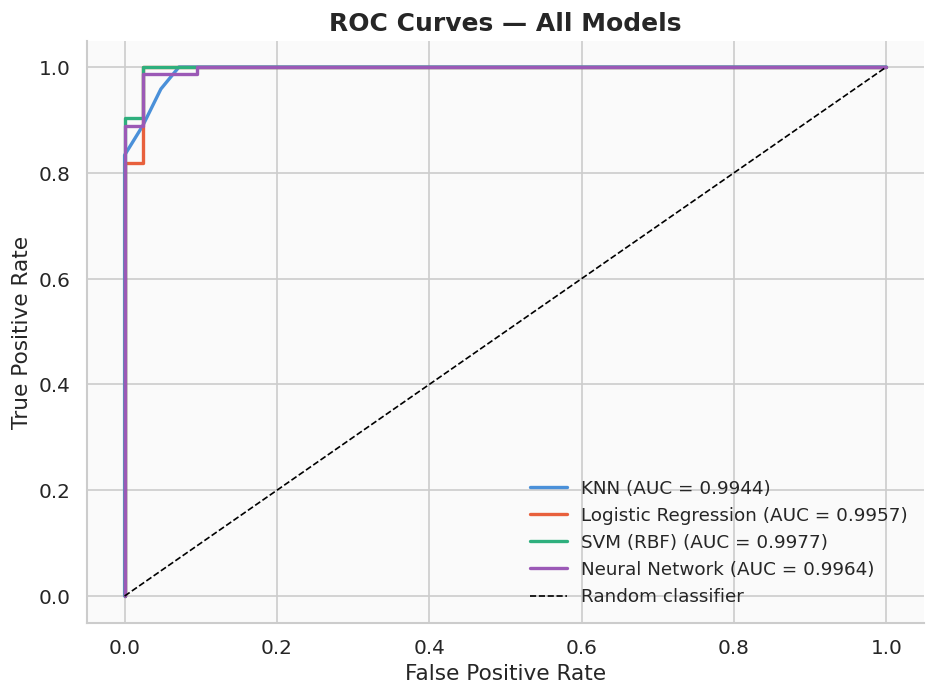

In [ ]:
from sklearn.metrics import roc_curve, auc, f1_score

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = auc(fpr_svm, tpr_svm)

fig, ax = plt.subplots(figsize=(8, 6))

roc_data = [
    ('KNN',                 fpr_knn,  tpr_knn,  auc_knn),
    ('Logistic Regression', fpr_lr,   tpr_lr,   auc_lr),
    ('SVM (RBF)',           fpr_svm,  tpr_svm,  auc_svm),
    ('Neural Network',      fpr_mlp,  tpr_mlp,  roc_auc_mlp),
]

for (name, fpr, tpr, auc_val), color in zip(roc_data, PALETTE):
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

In [ ]:
summary_rows = []
for name, model, y_pred, y_proba, t_time in [
    ('KNN',                 final_knn, final_knn.predict(X_test_scaled), y_proba_knn,  knn_train_time),
    ('Logistic Regression', final_lr,  y_pred_lr,                        y_score_lr,   lr_train_time),
    ('SVM (RBF)',           final_svm, y_pred_svm,                       y_proba_svm,  svm_train_time),
    ('Neural Network',      best_mlp,  best_mlp.predict(X_test_scaled),  y_prob_mlp,   mlp2_time),
]:
    fpr_i, tpr_i, _ = roc_curve(y_test, y_proba)
    summary_rows.append({
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_test, y_pred), 4),
        'F1 (macro)':     round(f1_score(y_test, y_pred, average='macro'), 4),
        'AUC':            round(auc(fpr_i, tpr_i), 4),
        'Train time (s)': round(t_time, 4),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Model,Accuracy,F1 (macro),AUC,Train time (s)
0,KNN,0.9737,0.9713,0.9944,0.0040
1,Logistic Regression,0.9825,0.9812,0.9957,0.0076
2,SVM (RBF),0.9825,0.9812,0.9977,0.0205
3,Neural Network,0.9737,0.9716,0.9964,0.1676


### Discussion

All four models achieve high AUC (≥ 0.99) and accuracy (≥ 96%) on this dataset, reflecting that the 30 scaled cytological features are highly discriminative.

**Logistic Regression** is the strongest candidate for clinical deployment. It matches the top accuracy of KNN, achieves near-perfect AUC, trains in milliseconds, and — critically — its coefficients are directly interpretable: clinicians can understand which morphological features drive the prediction. In a high-stakes medical setting, interpretability is as important as performance.

**SVM (RBF)** achieves the highest accuracy after tuning but is a black-box model and slower to tune via grid search. It is a strong option when predictive performance is the sole priority.

**KNN** is simple and competitive but scales poorly with larger datasets (prediction requires searching all training points), and offers no feature-level interpretability.

**Neural Network** performs well but requires more hyperparameter decisions and is the least interpretable of the four. Its marginal performance gain over Logistic Regression does not justify the added complexity for this dataset size.


---
## References

[1] Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1995). *Breast Cancer Wisconsin (Diagnostic) Data Set*. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)

[2] Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

[3] Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed., Ch. 7). Springer. — Cross-validation and data leakage.

[4] LeCun, Y., Bottou, L., Orr, G. B., & Müller, K.-R. (2012). Efficient BackProp. In *Neural Networks: Tricks of the Trade* (2nd ed., pp. 9–48). Springer. — Feature scaling for gradient descent.

[5] Tufte, E. R. (2001). *The Visual Display of Quantitative Information* (2nd ed.). Graphics Press. — Data visualisation principles.

[6] James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed., Ch. 3 & 5). Springer. — Feature preprocessing and train/test methodology.

[7] Cheng, W., & Yu, Z. (2025). A fast and interpretable logistic regression framework for breast tumor classification using the Wisconsin Diagnostic Dataset. medRxiv. https://doi.org/10.64898/2025.12.23.25342946

[8] Nadkarni, P. (2016) “Core technologies: Data mining and ‘big data’”, en Clinical Research Computing. Elsevier, pp. 187–204. https://doi.org/10.1016/B978-0-12-803130-8.00010-5